# Análise Exploratória Fases 1, 2 e 3

In [61]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

RAIZ = Path.cwd()
while not (RAIZ / "train.csv").exists() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

from Pipeline.eda import EDAConfig, classificar_colunas
from Pipeline.eda.estilo import (
    DIVERGENTE, EIXO, SERIE_1, SERIE_2, SERIE_3, STATUS,
    TINTA_SECUNDARIA, TINTA_SUAVE, aplicar_estilo,
)
from Pipeline.eda.fase2_eda import consolidar_alertas, descrever_variaveis
from Pipeline.eda.utils import (
    amostrar, contar_outliers_iqr, eta_quadrado, grade_de_paineis,
    limites_iqr, psi,
)

aplicar_estilo()

%matplotlib inline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print("Raiz do projeto:", RAIZ)

Raiz do projeto: d:\Code\Disputa_gecida


In [62]:
cfg = EDAConfig(
    target="Listening_Time_minutes",
    id_col="id",
    outdir=RAIZ / "outputs" / "eda_notebook",
    # Regras de domínio: condições que NÃO deveriam existir nos dados.
    regras_logicas=[
        "Listening_Time_minutes > Episode_Length_minutes",
        "Number_of_Ads > 10",
        "Episode_Length_minutes <= 0",
    ],
)

print("Alvo:", cfg.target)
print("Identificador:", cfg.id_col)
print("Limite de descarte por ausentes:", f"{cfg.limite_nan_coluna}%")
print("Limite de redundância entre preditoras:", f"|r| >= {cfg.limite_correlacao_alta}")

Alvo: Listening_Time_minutes
Identificador: id
Limite de descarte por ausentes: 50.0%
Limite de redundância entre preditoras: |r| >= 0.9


## 1.1 Leitura dos arquivos

In [63]:
train = pd.read_csv(RAIZ / "train.csv")
test = pd.read_csv(RAIZ / "test.csv")

print(f"train: {train.shape[0]:,} linhas × {train.shape[1]} colunas".replace(",", "."))
print(f"test:  {test.shape[0]:,} linhas × {test.shape[1]} colunas".replace(",", "."))

train.head()

train: 750.000 linhas × 12 colunas
test:  250.000 linhas × 11 colunas


,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.8100,Thursday,Night,NaN,0.0000,Positive,31.4200
1,1,Joke Junction,Episode 26,119.8000,Comedy,66.9500,Saturday,Afternoon,75.9500,2.0000,Negative,88.0124
2,2,Study Sessions,Episode 16,73.9000,Education,69.9700,Tuesday,Evening,8.9700,0.0000,Negative,44.9253
3,3,Digital Digest,Episode 45,67.1700,Technology,57.2200,Monday,Morning,78.7000,2.0000,Positive,46.2782
4,4,Mind & Body,Episode 86,110.5100,Health,80.0700,Monday,Afternoon,58.6800,3.0000,Neutral,75.6103


## 1.2 Alinhamento entre train e test

In [4]:
so_train = [c for c in train.columns if c not in test.columns]
so_test = [c for c in test.columns if c not in train.columns]
comuns = [c for c in train.columns if c in test.columns]
divergentes = [c for c in comuns if train[c].dtype != test[c].dtype]

pd.DataFrame([
    {"item": "colunas comuns", "quantidade": len(comuns), "colunas": ""},
    {"item": "só no train", "quantidade": len(so_train), "colunas": ", ".join(so_train)},
    {"item": "só no test", "quantidade": len(so_test), "colunas": ", ".join(so_test)},
    {"item": "dtypes divergentes", "quantidade": len(divergentes), "colunas": ", ".join(divergentes)},
])

,item,quantidade,colunas
0,colunas comuns,11,
1,só no train,1,Listening_Time_minutes
2,só no test,0,
3,dtypes divergentes,0,


## 1.3 Estabilidade das distribuições (PSI)

| PSI | Interpretação |
|---|---|
| < 0,10 | estável |
| 0,10 – 0,25 | merece atenção |
| > 0,25 | deslocamento forte |

In [64]:

linhas_psi = []
for c in comuns:
    if c in (cfg.id_col, cfg.target):
        continue
    valor = psi(train[c], test[c])
    numerica = pd.api.types.is_numeric_dtype(train[c])
    linhas_psi.append({
        "coluna": c,
        "nan_pct_train": round(100 * train[c].isna().mean(), 3),
        "nan_pct_test": round(100 * test[c].isna().mean(), 3),
        "psi": round(valor, 5),
        "diagnostico": "estável" if valor < 0.10 else ("atenção" if valor < 0.25 else "deslocamento forte"),
        "max_train": float(train[c].max()) if numerica else np.nan,
        "max_test": float(test[c].max()) if numerica else np.nan,
    })

estabilidade = pd.DataFrame(linhas_psi).sort_values("psi", ascending=False)
estabilidade

,coluna,nan_pct_train,nan_pct_test,psi,diagnostico,max_train,max_test
1,Episode_Title,0.0000,0.0000,0.0006,estável,NaN,NaN
0,Podcast_Name,0.0000,0.0000,0.0002,estável,NaN,NaN
7,Guest_Popularity_percentage,19.4710,19.5330,0.0001,estável,119.9100,116.8200
2,Episode_Length_minutes,11.6120,11.4940,0.0001,estável,325.2400,"78,486,264.0000"
4,Host_Popularity_percentage,0.0000,0.0000,0.0001,estável,119.4600,117.7600
3,Genre,0.0000,0.0000,0.0001,estável,NaN,NaN
5,Publication_Day,0.0000,0.0000,0.0000,estável,NaN,NaN
6,Publication_Time,0.0000,0.0000,0.0000,estável,NaN,NaN
8,Number_of_Ads,0.0000,0.0000,0.0000,estável,103.9100,"2,063.0000"
9,Episode_Sentiment,0.0000,0.0000,0.0000,estável,NaN,NaN


## 1.4 Max train max test diferença


In [65]:
linhas_fora = []
for c in comuns:
    if c in (cfg.id_col, cfg.target) or not pd.api.types.is_numeric_dtype(train[c]):
        continue
    minimo, maximo = train[c].min(), train[c].max()
    fora = int(((test[c] < minimo) | (test[c] > maximo)).sum())
    if fora:
        linhas_fora.append({
            "coluna": c,
            "linhas_do_test_fora_do_intervalo": fora,
            "max_train": maximo,
            "max_test": test[c].max(),
            "razao": test[c].max() / maximo,
        })

pd.DataFrame(linhas_fora)

,coluna,linhas_do_test_fora_do_intervalo,max_train,max_test,razao
0,Episode_Length_minutes,2,325.2400,"78,486,264.0000","241,317.9929"
1,Number_of_Ads,1,103.9100,"2,063.0000",19.8537


In [66]:
test.nlargest(3, "Episode_Length_minutes")[
    ["id", "Episode_Length_minutes", "Number_of_Ads", "Genre"]
]

,id,Episode_Length_minutes,Number_of_Ads,Genre
56597,806597,"78,486,264.0000",0.0000,Business
54434,804434,"7,575.0000",2.0000,News
180050,930050,120.7300,0.0000,Technology


### Comparação visual das distribuições

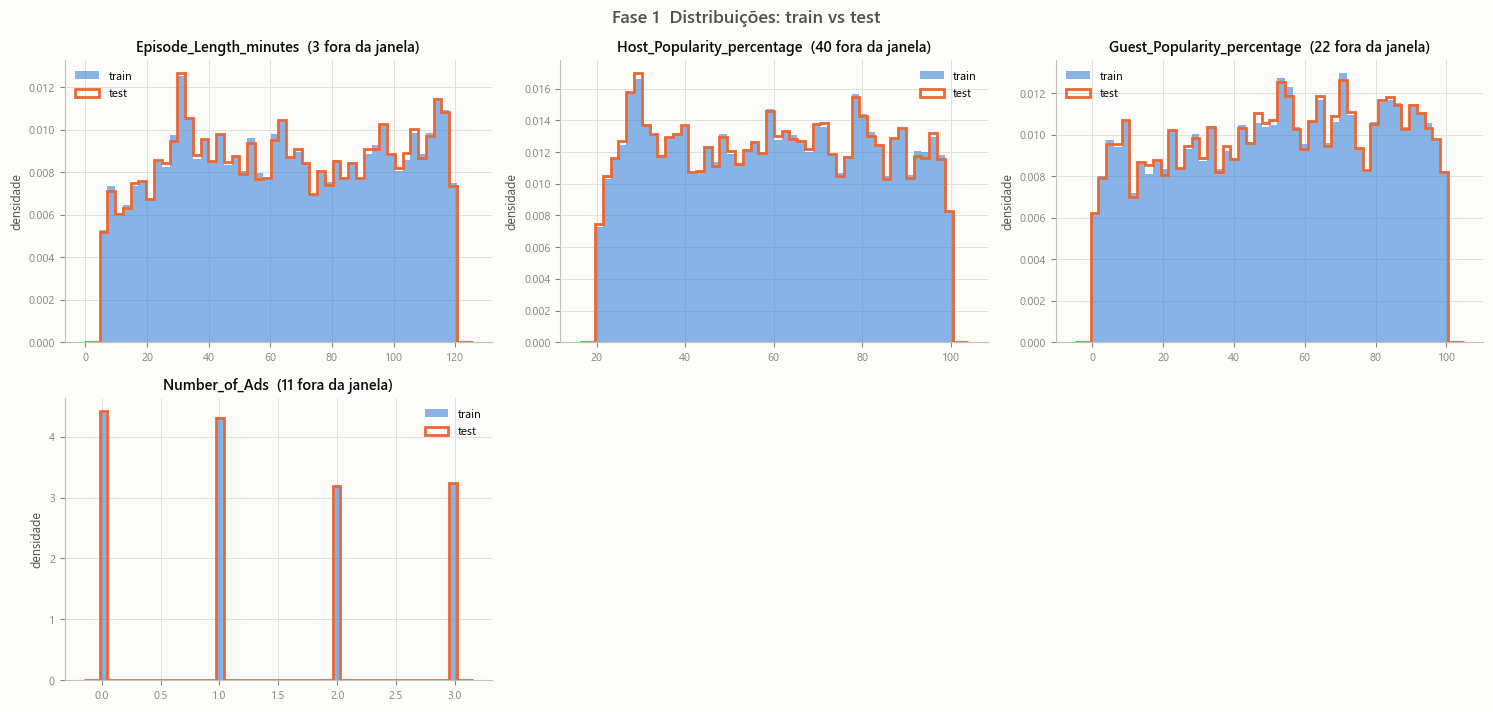

In [67]:
numericas_comuns = [
    c for c in comuns
    if c not in (cfg.id_col, cfg.target) and pd.api.types.is_numeric_dtype(train[c])
]

fig, axes = grade_de_paineis(len(numericas_comuns), cfg)
for ax, c in zip(axes, numericas_comuns):
    st, se = train[c].dropna(), test[c].dropna()
    juntas = pd.concat([st, se])
    inf, sup = juntas.quantile(0.001), juntas.quantile(0.999)
    margem = (sup - inf) * 0.05 or 1.0
    inf, sup = inf - margem, sup + margem
    n_fora = int(((juntas < inf) | (juntas > sup)).sum())

    faixas = np.linspace(inf, sup, 51)
    ax.hist(st.clip(inf, sup), bins=faixas, density=True, color=SERIE_1,
            alpha=0.55, label="train", edgecolor="none")
    ax.hist(se.clip(inf, sup), bins=faixas, density=True, histtype="step",
            color=SERIE_2, linewidth=2.0, label="test")
    ax.set_title(f"{c}" + (f"  ({n_fora} fora da janela)" if n_fora else ""))
    ax.set_ylabel("densidade")
    ax.legend()

fig.suptitle("Fase 1  Distribuições: train vs test", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Leitura:** dentro da janela robusta as duas curvas praticamente se sobrepõem 
o test é uma amostra da mesma população. O problema não é deslocamento de
distribuição, é um punhado de registros corrompidos.

Repare também no formato: Episode_Length_minutes, Host_Popularity_percentage e
Guest_Popularity_percentage são **quase uniformes**, não normais. Isso já
antecipa por que a regra IQR não vai encontrar outliers (seção 2.3).

# Análise Exploratória (EDA)


## 2.1 Descrição das variáveis

In [68]:
colunas = classificar_colunas(train, cfg)

print("numéricas:          ", colunas.numericas)
print("categóricas:        ", colunas.categoricas)
print("alta cardinalidade: ", colunas.alta_cardinalidade)
print("identificadores:    ", colunas.identificadores)
print("constantes:         ", colunas.constantes)

numéricas:           ['Episode_Length_minutes', 'Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Number_of_Ads']
categóricas:         ['Podcast_Name', 'Genre', 'Publication_Day', 'Publication_Time', 'Episode_Sentiment']
alta cardinalidade:  ['Episode_Title']
identificadores:     []
constantes:          []


In [11]:
descricao = descrever_variaveis(train, cfg, colunas)
descricao

,coluna,papel,dtype,n_preenchidos,n_nan,nan_pct,nunique,unicidade_pct,valor_dominante,dominante_pct,memoria_MB
0,id,id,int64,750000,0,0.0000,750000,100.0000,0,0.0000,5.7220
1,Podcast_Name,categorica,object,750000,0,0.0000,48,0.0060,Tech Talks,3.0460,44.1750
2,Episode_Title,alta cardinalidade,object,750000,0,0.0000,100,0.0130,Episode 71,1.4020,42.1500
3,Episode_Length_minutes,numerica,float64,662907,87093,11.6120,12268,1.6360,6.6000,0.1230,5.7220
4,Genre,categorica,object,750000,0,0.0000,10,0.0010,Sports,11.6810,40.3420
5,Host_Popularity_percentage,numerica,float64,750000,0,0.0000,8038,1.0720,38.6800,0.0750,5.7220
6,Publication_Day,categorica,object,750000,0,0.0000,7,0.0010,Sunday,15.4590,40.1380
7,Publication_Time,categorica,object,750000,0,0.0000,4,0.0010,Night,26.2470,40.0210
8,Guest_Popularity_percentage,numerica,float64,603970,146030,19.4710,10019,1.3360,68.5300,0.0500,5.7220
9,Number_of_Ads,numerica,float64,749999,1,0.0000,12,0.0020,0.0000,29.0120,5.7220


### Valores ausentes

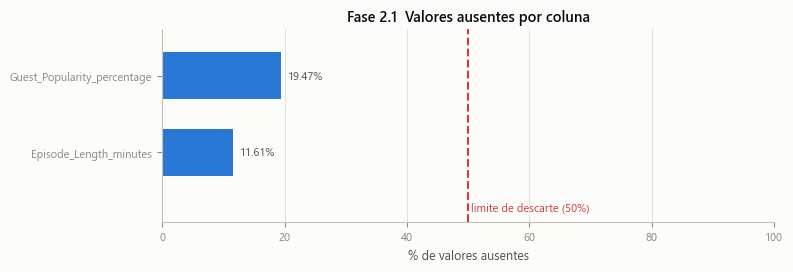

In [69]:
com_nan = descricao[descricao["nan_pct"] > 0].sort_values("nan_pct")

fig, ax = plt.subplots(figsize=(8, 2.8))
pos = np.arange(len(com_nan))
ax.barh(pos, com_nan["nan_pct"], color=SERIE_1, height=0.6)
ax.set_yticks(pos, com_nan["coluna"])
ax.set_xlabel("% de valores ausentes")
ax.set_title("Fase 2.1  Valores ausentes por coluna")
ax.axvline(cfg.limite_nan_coluna, color=STATUS["critico"], linewidth=1.5, linestyle="--")
ax.set_ylim(-0.9, len(com_nan) - 0.4)
ax.text(cfg.limite_nan_coluna, -0.8, f" limite de descarte ({cfg.limite_nan_coluna:.0f}%)",
        color=STATUS["critico"], fontsize=8, va="bottom")
ax.set_xlim(0, 100)
ax.grid(axis="y", visible=False)
for y, v in zip(pos, com_nan["nan_pct"]):
    ax.text(v + 1, y, f"{v:.2f}%", va="center", fontsize=8, color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

## 2.2 Distribuição da variável alvo

In [70]:
alvo = train[cfg.target].dropna()
n_out_alvo, pct_out_alvo = contar_outliers_iqr(alvo)
amostra_alvo = alvo.sample(n=5000, random_state=cfg.random_state)
_, p_normal = stats.normaltest(amostra_alvo)

pd.DataFrame([
    {"metrica": "n", "valor": len(alvo)},
    {"metrica": "média", "valor": alvo.mean()},
    {"metrica": "mediana", "valor": alvo.median()},
    {"metrica": "desvio padrão", "valor": alvo.std()},
    {"metrica": "mínimo", "valor": alvo.min()},
    {"metrica": "p25", "valor": alvo.quantile(0.25)},
    {"metrica": "p75", "valor": alvo.quantile(0.75)},
    {"metrica": "p99", "valor": alvo.quantile(0.99)},
    {"metrica": "máximo", "valor": alvo.max()},
    {"metrica": "skewness (assimetria)", "valor": alvo.skew()},
    {"metrica": "kurtosis (excesso)", "valor": alvo.kurt()},
    {"metrica": "% de zeros", "valor": 100 * (alvo == 0).mean()},
    {"metrica": "% negativos", "valor": 100 * (alvo < 0).mean()},
    {"metrica": "outliers IQR", "valor": n_out_alvo},
    {"metrica": "p-valor normalidade (D'Agostino, n=5k)", "valor": p_normal},
])

,metrica,valor
0,n,"750,000.0000"
1,média,45.4374
2,mediana,43.3795
3,desvio padrão,27.1383
4,mínimo,0.0000
5,p25,23.1783
6,p75,64.8116
7,p99,109.3963
8,máximo,119.9700
9,skewness (assimetria),0.3508


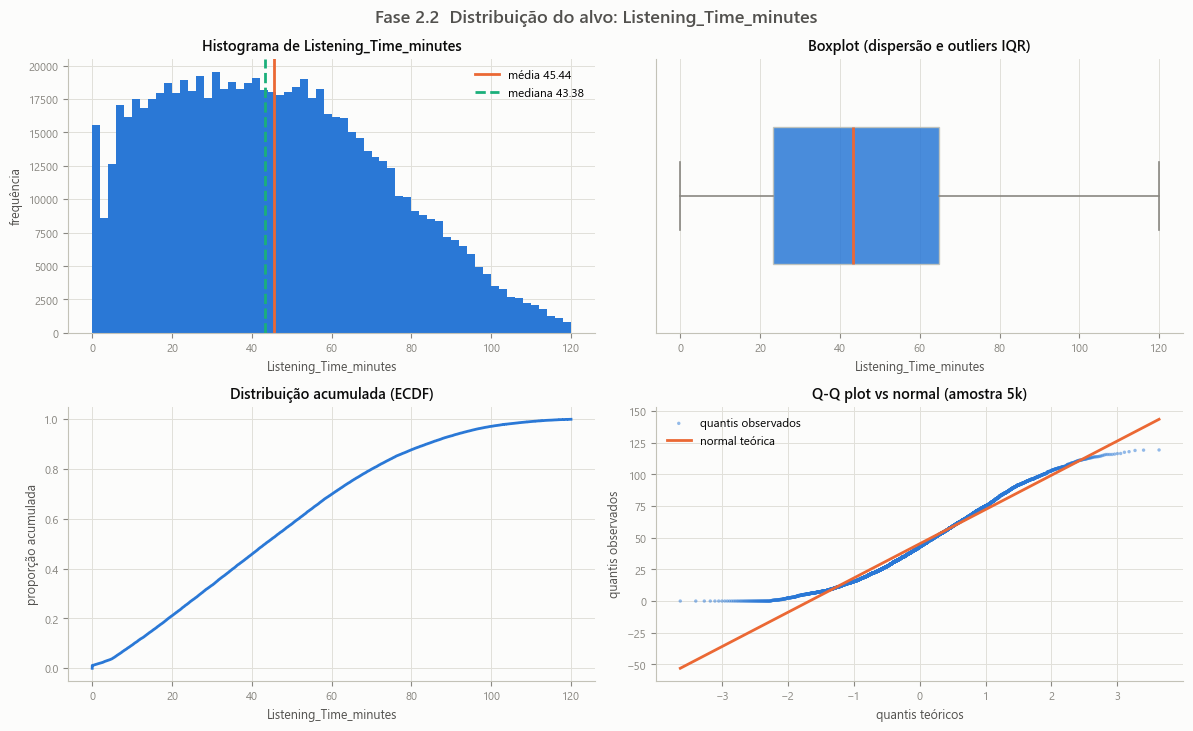

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.4))

ax = axes[0, 0]
ax.hist(alvo, bins=60, color=SERIE_1, edgecolor="none")
ax.axvline(alvo.mean(), color=SERIE_2, linewidth=2, label=f"média {alvo.mean():.2f}")
ax.axvline(alvo.median(), color=SERIE_3, linewidth=2, linestyle="--",
           label=f"mediana {alvo.median():.2f}")
ax.set_title(f"Histograma de {cfg.target}")
ax.set_xlabel(cfg.target); ax.set_ylabel("frequência"); ax.legend()

ax = axes[0, 1]
cx = ax.boxplot(alvo, vert=False, widths=0.5, patch_artist=True,
                flierprops={"marker": ".", "markersize": 2,
                            "markerfacecolor": TINTA_SUAVE,
                            "markeredgecolor": "none", "alpha": 0.3})
cx["boxes"][0].set(facecolor=SERIE_1, edgecolor=EIXO, alpha=0.85)
for el in ("whiskers", "caps"):
    for a in cx[el]:
        a.set(color=TINTA_SUAVE, linewidth=1.2)
cx["medians"][0].set(color=SERIE_2, linewidth=2)
ax.set_title("Boxplot (dispersão e outliers IQR)")
ax.set_xlabel(cfg.target); ax.set_yticks([]); ax.grid(axis="y", visible=False)

ax = axes[1, 0]
ordenado = np.sort(alvo.to_numpy())
ax.plot(ordenado, np.arange(1, len(ordenado) + 1) / len(ordenado), color=SERIE_1)
ax.set_title("Distribuição acumulada (ECDF)")
ax.set_xlabel(cfg.target); ax.set_ylabel("proporção acumulada")

ax = axes[1, 1]
(osm, osr), (incl, interc, _) = stats.probplot(amostra_alvo, dist="norm")
ax.scatter(osm, osr, s=6, color=SERIE_1, alpha=0.5, edgecolors="none",
           label="quantis observados")
ax.plot(osm, incl * osm + interc, color=SERIE_2, label="normal teórica")
ax.set_title("Q-Q plot vs normal (amostra 5k)")
ax.set_xlabel("quantis teóricos"); ax.set_ylabel("quantis observados"); ax.legend()

fig.suptitle(f"Fase 2.2  Distribuição do alvo: {cfg.target}", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()



**Leitura:**

- **Assimetria leve** (skewness 0,35) e **caudas curtas** (kurtosis −0,66, ou seja,
  achatada em relação à normal). O alvo **não** é fortemente enviesado à direita,
  que é o caso típico em que se aplicaria `log1p`. Aqui essa transformação não é
  necessária e provavelmente atrapalharia.
- **Zero outliers pela regra IQR.** A distribuição é larga e sem caudas longas.
- **O Q-Q plot mostra o desvio da normal nas duas pontas**, com um "piso" achatado
  perto de zero: 1,14% das observações são exatamente **0**. São ouvintes que
  abriram o episódio e não escutaram nada  um comportamento qualitativamente
  diferente do resto, que vale investigar antes de modelar.
- O teste de normalidade rejeita a hipótese nula (p ≈ 6e−74), mas com 750 mil
  observações qualquer desvio mínimo seria rejeitado. **A forma do gráfico informa
  mais do que o p-valor.**
- O alvo está limitado a **[0; 120]**. Nada impede um modelo de regressão de prever
  valores negativos ou acima de 120  vale recortar as previsões nesse intervalo
  na Fase 5.

**Implicação para as métricas (Fase 4):** distribuição sem cauda longa e sem
transformação necessária **RMSE** é uma escolha adequada como métrica principal.
O RMSLE previsto no diagrama faz menos sentido aqui (ele penaliza erro relativo,
útil quando o alvo cobre várias ordens de grandeza  não é o caso).

## 2.3 Análise das variáveis numéricas

In [72]:
linhas_num = []
for c in colunas.numericas:
    serie = train[c].dropna()
    inf, sup = limites_iqr(serie)
    n_out, pct_out = contar_outliers_iqr(serie)
    linhas_num.append({
        "coluna": c,
        "n": len(serie),
        "nan_pct": round(100 * train[c].isna().mean(), 3),
        "media": serie.mean(),
        "mediana": serie.median(),
        "desvio": serie.std(),
        "min": serie.min(),
        "max": serie.max(),
        "skew": serie.skew(),
        "kurtosis": serie.kurt(),
        "iqr_inf": inf,
        "iqr_sup": sup,
        "outliers_iqr": n_out,
        "outliers_pct": round(pct_out, 4),
        "zeros_pct": round(100 * (serie == 0).mean(), 3),
        "n_valores_distintos": serie.nunique(),
    })

resumo_num = pd.DataFrame(linhas_num)
resumo_num

,coluna,n,nan_pct,media,mediana,desvio,min,max,skew,kurtosis,iqr_inf,iqr_sup,outliers_iqr,outliers_pct,zeros_pct,n_valores_distintos
0,Episode_Length_minutes,662907,11.6120,64.5047,63.8400,32.9696,0.0000,325.2400,-0.0020,-1.2030,-51.7800,181.5800,1,0.0002,0.0000,12268
1,Host_Popularity_percentage,750000,0.0000,59.8599,60.0500,22.8731,1.3000,119.4600,0.0049,-1.2067,-20.7700,139.7100,0,0.0000,0.0000,8038
2,Guest_Popularity_percentage,603970,19.4710,52.2364,53.5800,28.4512,0.0000,119.9100,-0.1070,-1.1501,-43.9500,148.9300,0,0.0000,0.0000,10019
3,Number_of_Ads,749999,0.0000,1.3489,1.0000,1.1511,0.0000,103.9100,6.0330,505.8939,-3.0000,5.0000,9,0.0012,29.0120,12


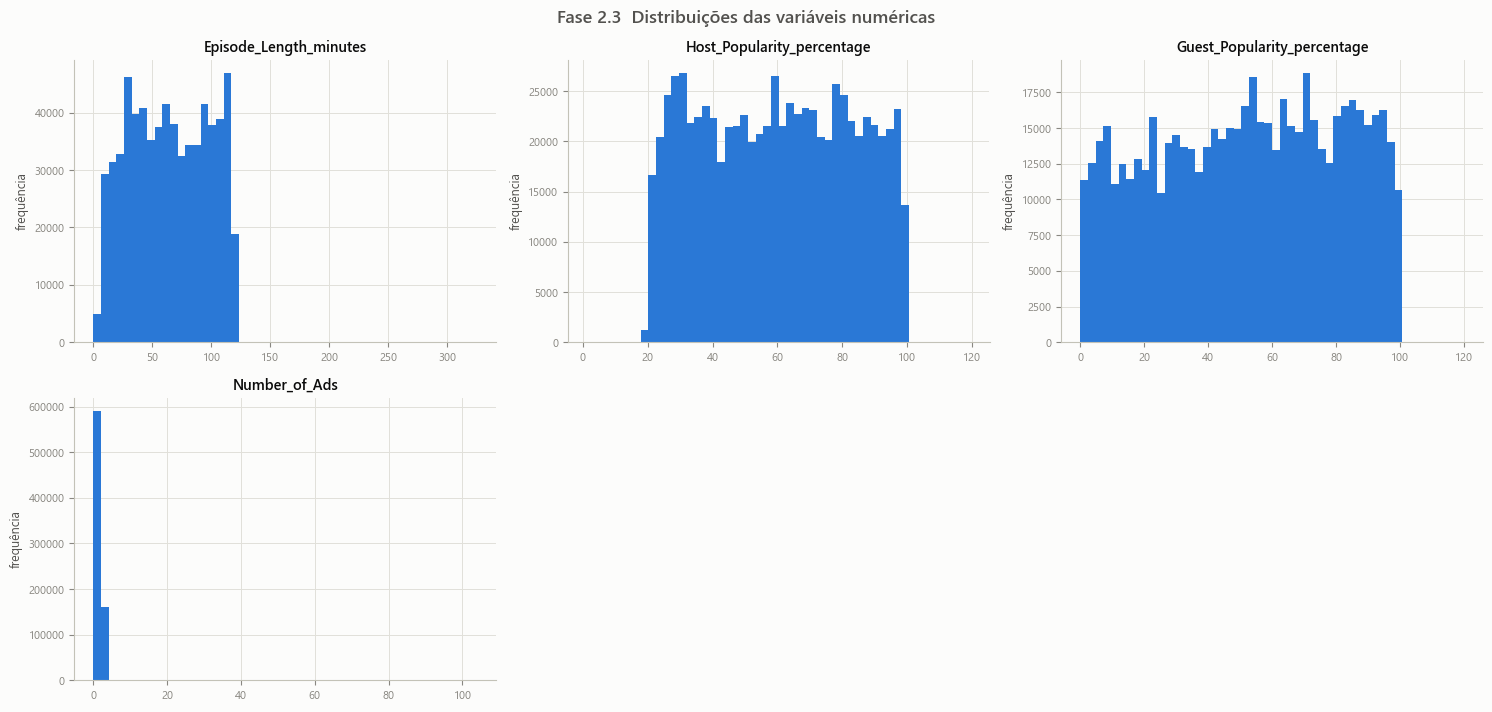

In [16]:
fig, axes = grade_de_paineis(len(colunas.numericas), cfg)
for ax, c in zip(axes, colunas.numericas):
    ax.hist(train[c].dropna(), bins=50, color=SERIE_1, edgecolor="none")
    ax.set_title(c)
    ax.set_ylabel("frequência")
fig.suptitle("Fase 2.3  Distribuições das variáveis numéricas", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

### Outliers pela regra IQR

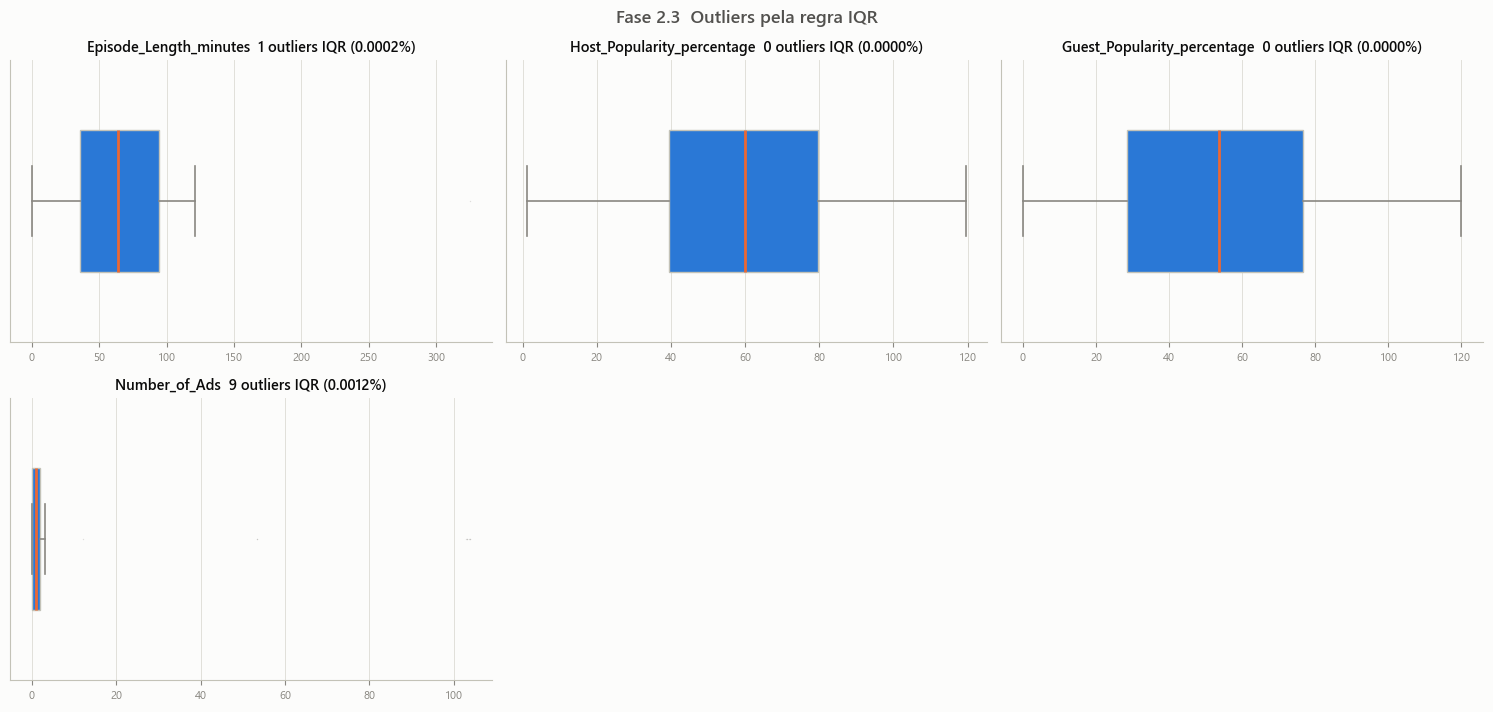

In [73]:
fig, axes = grade_de_paineis(len(colunas.numericas), cfg)
for ax, c in zip(axes, colunas.numericas):
    serie = train[c].dropna()
    cx = ax.boxplot(serie, vert=False, widths=0.5, patch_artist=True,
                    flierprops={"marker": ".", "markersize": 2,
                                "markerfacecolor": TINTA_SUAVE,
                                "markeredgecolor": "none", "alpha": 0.25})
    cx["boxes"][0].set(facecolor=SERIE_1, edgecolor=EIXO, alpha=1)
    for el in ("whiskers", "caps"):
        for a in cx[el]:
            a.set(color=TINTA_SUAVE, linewidth=1.2)
    cx["medians"][0].set(color=SERIE_2, linewidth=2)
    n_out, pct_out = contar_outliers_iqr(serie)
    ax.set_title(f"{c}  {n_out} outliers IQR ({pct_out:.4f}%)")
    ax.set_yticks([]); ax.grid(axis="y", visible=False)
fig.suptitle("Fase 2.3  Outliers pela regra IQR", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Achado importante  a regra IQR é praticamente inócua neste dataset.**

| coluna | limite superior IQR | máximo observado | outliers |
|---|---|---|---|
| Episode_Length_minutes | 181,6 | 325,2 | **1** em 662.907 |
| Host_Popularity_percentage | 139,7 | 119,5 | **0** |
| Guest_Popularity_percentage | 148,9 | 119,9 | **0** |
| Number_of_Ads | 5,0 | 103,9 | **9** |

O motivo está nos histogramas acima: as três primeiras variáveis são **quase
uniformes** (kurtosis ≈ −1,2). Uma distribuição uniforme tem quartis muito
afastados, o que empurra os limites do IQR para longe  no caso de
Host_Popularity_percentage, para 139,7, um valor que a variável nunca alcança.

Isso tem uma consequência direta no plano do diagrama, que prevê "IQR clipping ·
winsorization · z-score > 3" na Fase 3: **esse tratamento não removeria os erros
reais dos dados**. Percentuais de 119% passariam intactos, porque estatisticamente
eles não são extremos  são apenas impossíveis.

Os erros de verdade são pegos por **regras de domínio** (seção 2.6), não por
estatística descritiva.

Number_of_Ads é o caso oposto e igualmente instrutivo: skewness de **6,03** e
kurtosis de **506** produzidas por apenas 9 valores corrompidos (até 103,91) numa
variável cuja escala real é 0 a 3. Um punhado de erros distorce completamente as
estatísticas de forma.

### Relação de cada numérica com o alvo

A dispersão usa uma amostra de 20 mil linhas (750 mil pontos empastariam o
gráfico). A linha laranja é a **média do alvo por decil** da variável, calculada
sobre a base completa  ela revela a forma da relação, inclusive se for não linear.

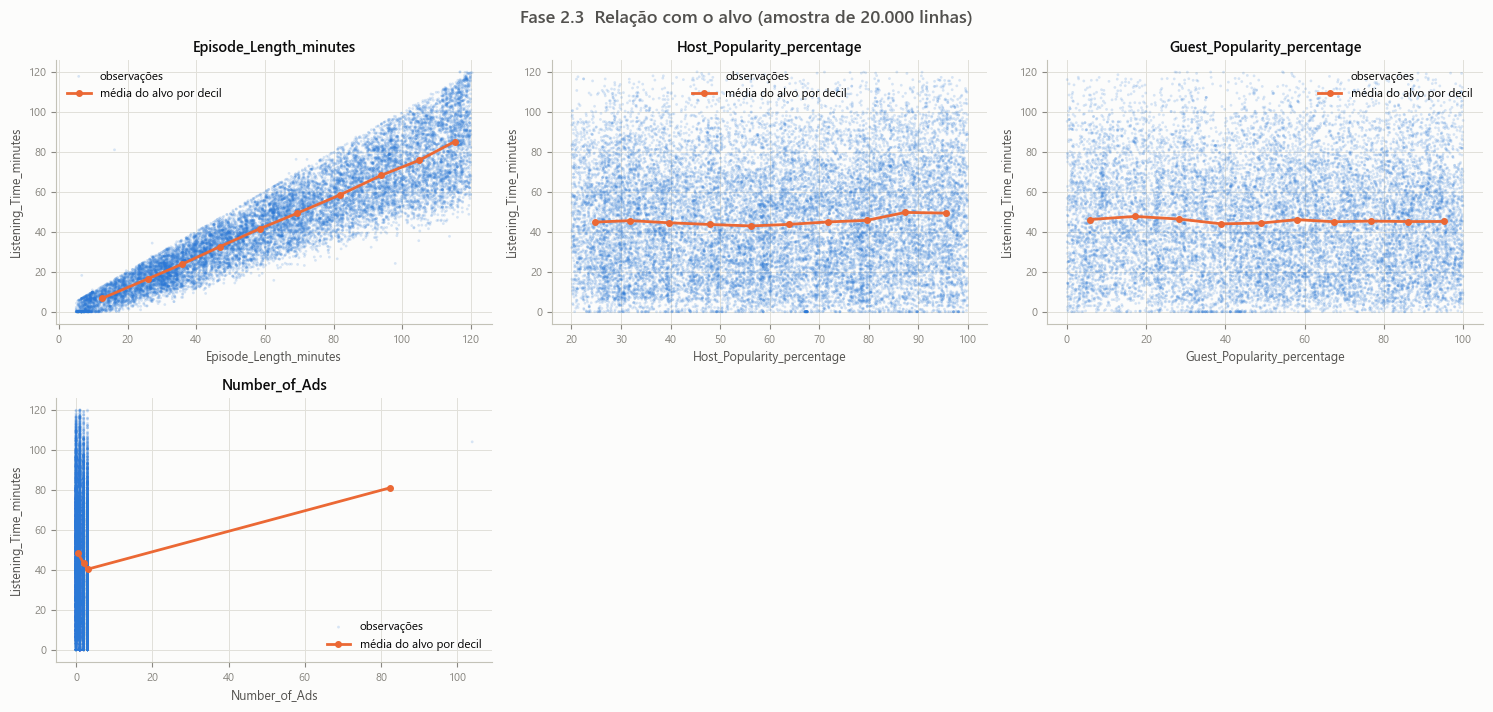

In [74]:
amostra = amostrar(train[colunas.numericas + [cfg.target]], cfg.amostra_scatter, cfg.random_state)

fig, axes = grade_de_paineis(len(colunas.numericas), cfg)
for ax, c in zip(axes, colunas.numericas):
    par = amostra[[c, cfg.target]].dropna()
    ax.scatter(par[c], par[cfg.target], s=4, alpha=0.18, color=SERIE_1,
               edgecolors="none", label="observações")
    completo = train[[c, cfg.target]].dropna()
    faixas = pd.qcut(completo[c], q=10, duplicates="drop")
    perfil = completo.groupby(faixas, observed=True).agg(x=(c, "mean"), y=(cfg.target, "mean"))
    ax.plot(perfil["x"], perfil["y"], color=SERIE_2, marker="o", markersize=4,
            label="média do alvo por decil")
    ax.set_title(c); ax.set_xlabel(c); ax.set_ylabel(cfg.target); ax.legend()

fig.suptitle("Fase 2.3  Relação com o alvo (amostra de 20.000 linhas)", fontsize=13,
             fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

In [75]:
linhas_corr = []
for c in colunas.numericas:
    par = train[[c, cfg.target]].dropna()
    linhas_corr.append({
        "coluna": c,
        "pearson": par[c].corr(par[cfg.target]),
        "spearman": par[c].corr(par[cfg.target], method="spearman"),
        "n_pares": len(par),
    })

corr_alvo = (pd.DataFrame(linhas_corr)
             .assign(abs_pearson=lambda d: d["pearson"].abs())
             .sort_values("abs_pearson", ascending=False)
             .drop(columns="abs_pearson"))
corr_alvo

,coluna,pearson,spearman,n_pares
0,Episode_Length_minutes,0.9167,0.9317,662907
3,Number_of_Ads,-0.1183,-0.1153,749999
1,Host_Popularity_percentage,0.0509,0.0454,750000
2,Guest_Popularity_percentage,-0.0160,-0.0145,603970


**Leitura  este é o achado central do projeto:**

| variável | Pearson | Spearman |
|---|---|---|
| `Episode_Length_minutes` | **0,917** | **0,932** |
| `Number_of_Ads` | −0,118 | −0,115 |
| `Host_Popularity_percentage` | 0,051 | 0,045 |
| `Guest_Popularity_percentage` | −0,016 | −0,015 |

**Episode_Length_minutes sozinha explica ~84% da variância do alvo** (0,917² = 0,84).
O gráfico de dispersão mostra por quê: os pontos formam uma faixa triangular bem
definida, com o alvo limitado superiormente pela duração do episódio  faz sentido,
não se escuta mais tempo do que o episódio dura. E a média por decil é uma reta

## 2.4 Análise das variáveis categóricas

In [76]:
todas_cat = colunas.todas_categoricas
linhas_cat = []
detalhes_cat = {}

for c in todas_cat:
    agrupado = (train.groupby(c, observed=True)[cfg.target]
                .agg(n="count", media="mean", mediana="median", desvio="std")
                .reset_index())
    agrupado["freq_pct"] = round(100 * agrupado["n"] / len(train), 3)
    detalhes_cat[c] = agrupado.sort_values("media", ascending=False)

    eta2 = eta_quadrado(train, c, cfg.target)
    linhas_cat.append({
        "coluna": c,
        "n_categorias": train[c].nunique(),
        "nan_pct": round(100 * train[c].isna().mean(), 3),
        "categoria_dominante": agrupado.loc[agrupado["n"].idxmax(), c],
        "dominante_pct": agrupado["freq_pct"].max(),
        "media_alvo_min": agrupado["media"].min(),
        "media_alvo_max": agrupado["media"].max(),
        "amplitude_media_alvo": agrupado["media"].max() - agrupado["media"].min(),
        "eta2_vs_alvo": round(eta2, 5),
    })

resumo_cat = pd.DataFrame(linhas_cat).sort_values("eta2_vs_alvo", ascending=False)
resumo_cat

,coluna,n_categorias,nan_pct,categoria_dominante,dominante_pct,media_alvo_min,media_alvo_max,amplitude_media_alvo,eta2_vs_alvo
5,Episode_Title,100,0.0000,Episode 71,1.4020,40.6211,51.2217,10.6006,0.0058
0,Podcast_Name,48,0.0000,Tech Talks,3.0460,41.8003,48.1056,6.3052,0.0026
4,Episode_Sentiment,3,0.0000,Neutral,33.5050,44.0968,46.7238,2.6270,0.0016
3,Publication_Time,4,0.0000,Night,26.2470,44.7616,46.4567,1.6951,0.0006
1,Genre,10,0.0000,Sports,11.6810,44.4061,46.5784,2.1722,0.0006
2,Publication_Day,7,0.0000,Sunday,15.4590,44.8174,46.1314,1.3140,0.0003


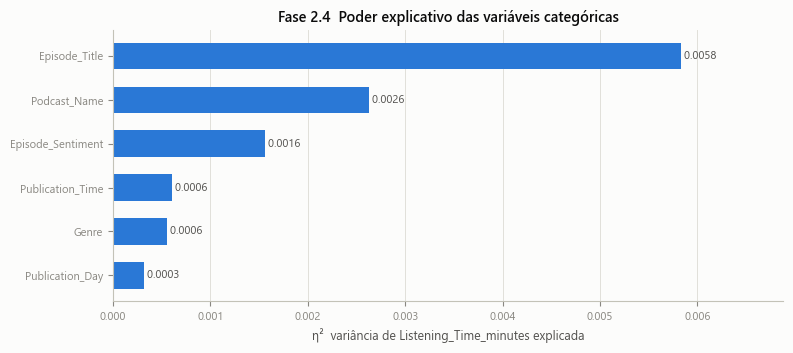

In [27]:
ordenado = resumo_cat.sort_values("eta2_vs_alvo")

fig, ax = plt.subplots(figsize=(8, 3.6))
pos = np.arange(len(ordenado))
ax.barh(pos, ordenado["eta2_vs_alvo"], color=SERIE_1, height=0.6)
ax.set_yticks(pos, ordenado["coluna"])
ax.set_xlabel(f"η²  variância de {cfg.target} explicada")
ax.set_title("Fase 2.4  Poder explicativo das variáveis categóricas")
ax.set_xlim(0, ordenado["eta2_vs_alvo"].max() * 1.18)
ax.grid(axis="y", visible=False)
for y, v in zip(pos, ordenado["eta2_vs_alvo"]):
    ax.text(v, y, f" {v:.4f}", va="center", fontsize=8, color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

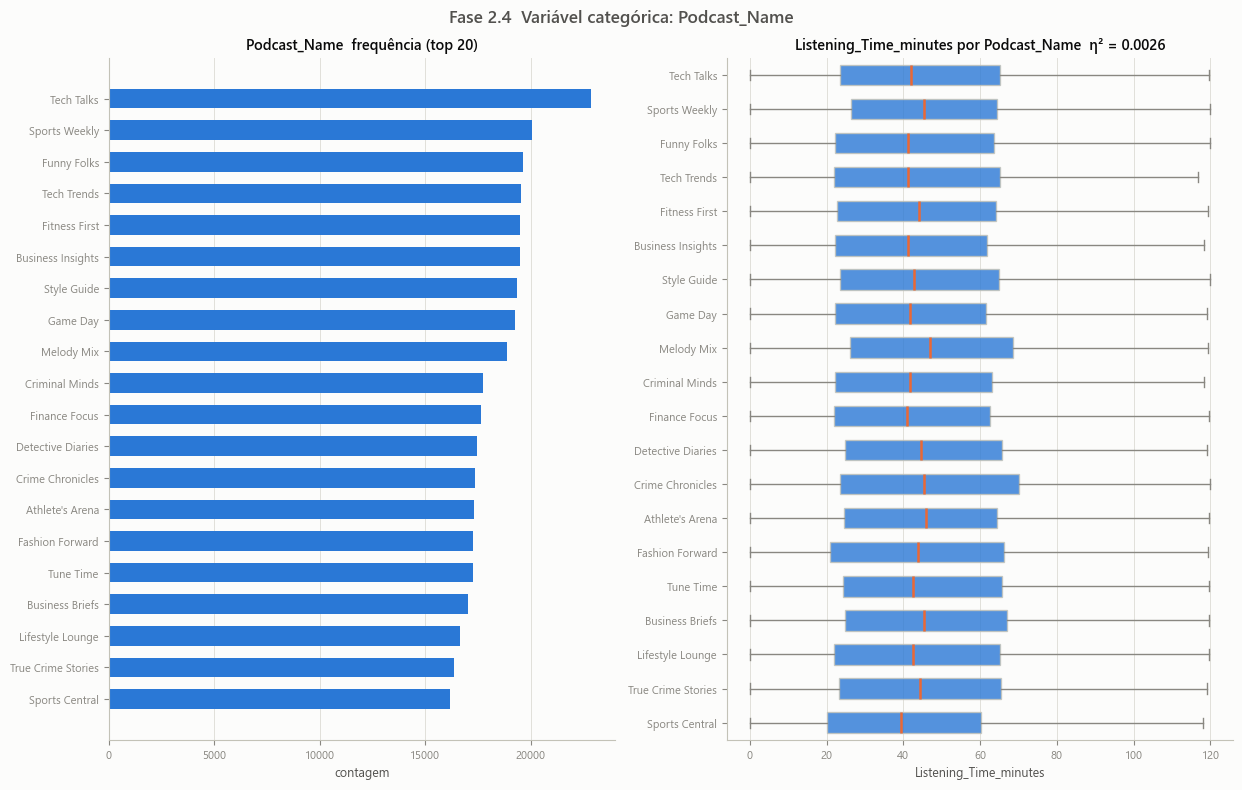

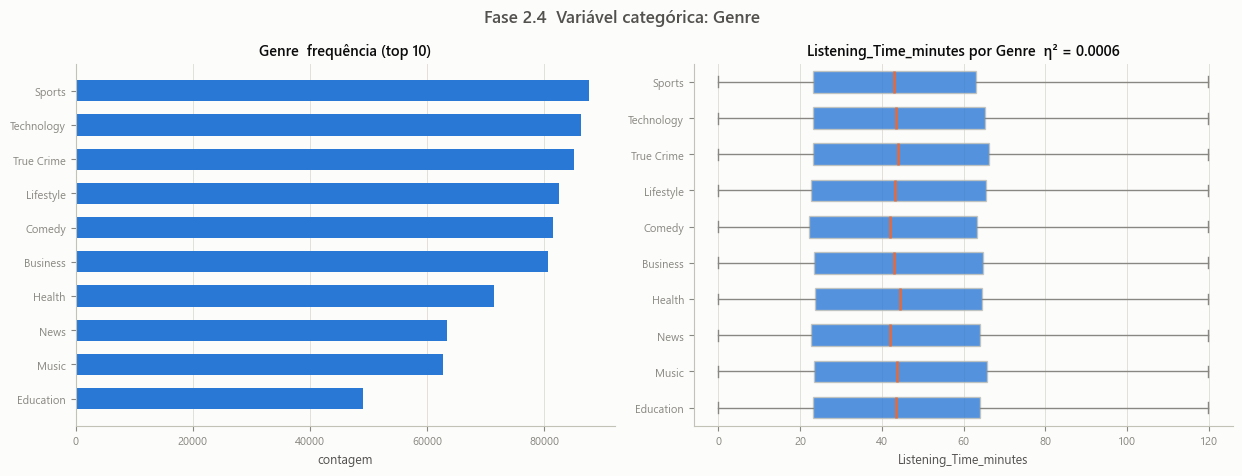

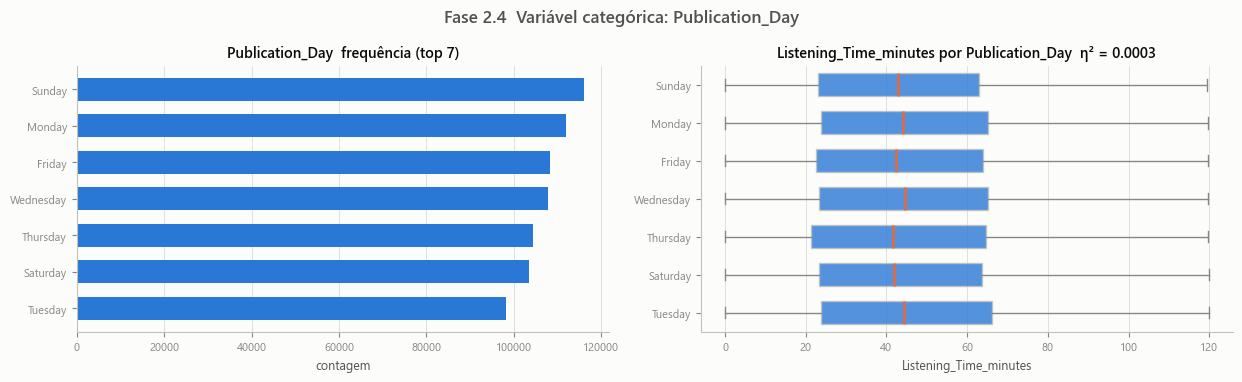

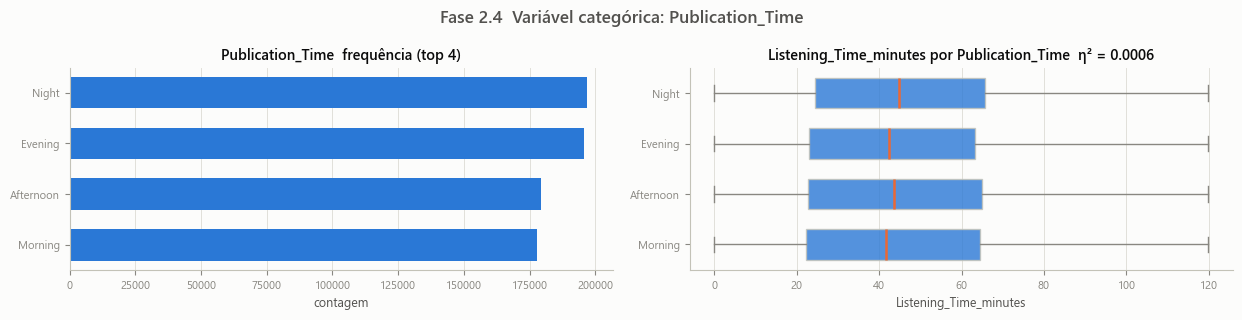

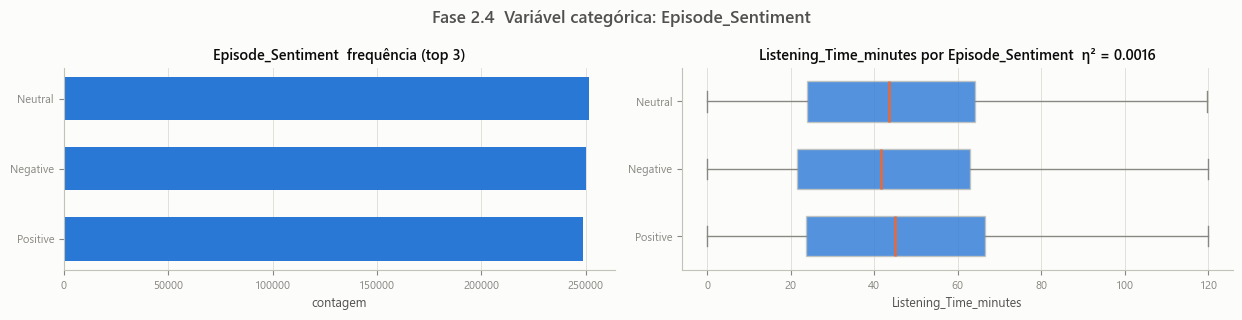

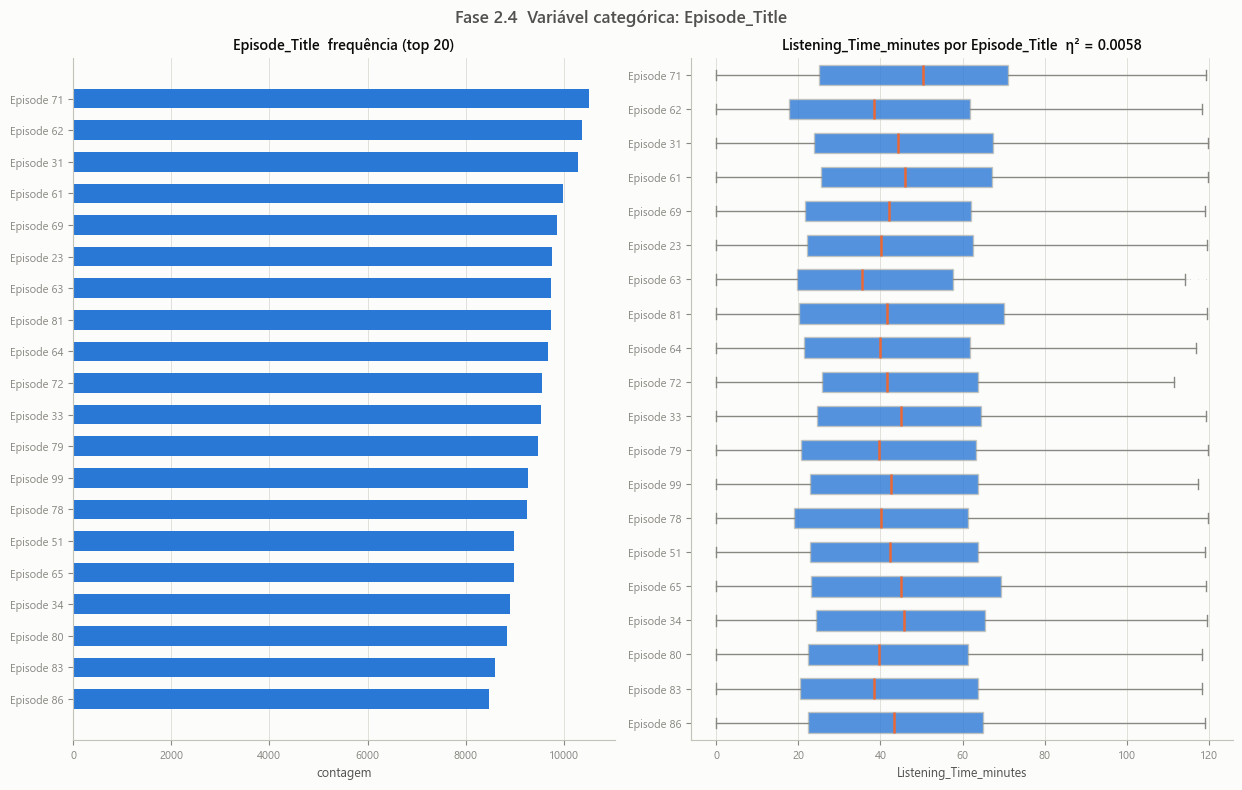

In [78]:
amostra_box = amostrar(train, cfg.amostra_boxplot, cfg.random_state)

for c in todas_cat:
    agrupado = detalhes_cat[c]
    top = agrupado.nlargest(cfg.top_n_categorias, "n").sort_values("n")
    niveis = top[c].tolist()
    altura = max(3.2, 0.32 * len(niveis) + 1.6)

    fig, (ax_freq, ax_alvo) = plt.subplots(1, 2, figsize=(12.5, altura))
    pos = np.arange(len(niveis))

    ax_freq.barh(pos, top["n"], color=SERIE_1, height=0.62)
    ax_freq.set_yticks(pos, [str(v) for v in niveis])
    ax_freq.set_xlabel("contagem")
    ax_freq.set_title(f"{c}  frequência (top {len(niveis)})")
    ax_freq.grid(axis="y", visible=False)

    grupos = [amostra_box.loc[amostra_box[c] == n, cfg.target].dropna().to_numpy()
              for n in niveis]
    cx = ax_alvo.boxplot(grupos, vert=False, widths=0.6, patch_artist=True,
                         flierprops={"marker": ".", "markersize": 1.5,
                                     "markerfacecolor": TINTA_SUAVE,
                                     "markeredgecolor": "none", "alpha": 0.2})
    for a in cx["boxes"]:
        a.set(facecolor=SERIE_1, edgecolor=EIXO, alpha=0.8)
    for el in ("whiskers", "caps"):
        for a in cx[el]:
            a.set(color=TINTA_SUAVE, linewidth=1.0)
    for a in cx["medians"]:
        a.set(color=SERIE_2, linewidth=1.8)
    ax_alvo.set_yticks(pos + 1, [str(v) for v in niveis])
    ax_alvo.set_xlabel(cfg.target)
    eta2 = float(resumo_cat.loc[resumo_cat["coluna"] == c, "eta2_vs_alvo"].iloc[0])
    ax_alvo.set_title(f"{cfg.target} por {c}  η² = {eta2:.4f}")
    ax_alvo.grid(axis="y", visible=False)

    fig.suptitle(f"Fase 2.4  Variável categórica: {c}", fontsize=12.5,
                 fontweight="semibold", color=TINTA_SECUNDARIA)
    fig.tight_layout()
    plt.show()

**Leitura dos boxplots:** em todas as variáveis as caixas estão praticamente
alinhadas  as medianas mal se deslocam de uma categoria para outra. Visualmente
é a mesma conclusão do η².

Duas observações úteis para a Fase 3:

- **`Episode_Title` tem 100 categorias e `Podcast_Name` tem 48.** One-Hot Encoding
  nelas adicionaria 148 colunas para capturar menos de 1% de variância. *Target
  encoding* ou agrupamento são alternativas mais econômicas  se é que vale manter
  essas colunas.
- **`Episode_Title` é o texto "Episode N"**, com N de 1 a 100. É um número
  disfarçado de texto. Extrair o inteiro seria o caminho natural, mas isso já é
  engenharia de features (fora do escopo deste notebook)  fica registrado para a
  fase seguinte.
- Nenhuma categoria domina o dataset (a maior concentração é `Publication_Time =
  Night`, com 26%), então não há colunas quase constantes para descartar.

## 2.5 Matriz de correlação

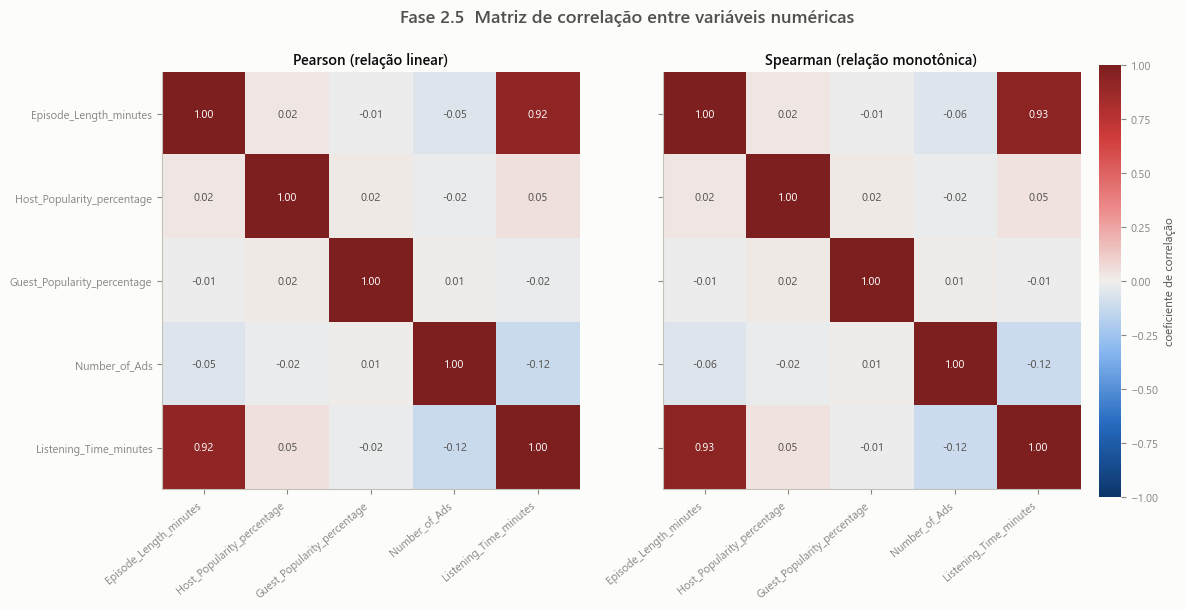

In [79]:
nums_corr = colunas.numericas + [cfg.target]
pearson = train[nums_corr].corr(method="pearson")
spearman = train[nums_corr].corr(method="spearman")

def desenhar_heatmap(ax, matriz, titulo, rotular_y):
    img = ax.imshow(matriz.to_numpy(), cmap=DIVERGENTE, vmin=-1, vmax=1)
    rotulos = list(matriz.columns)
    ax.set_xticks(range(len(rotulos)), rotulos, rotation=40, ha="right")
    ax.set_yticks(range(len(rotulos)), rotulos if rotular_y else [""] * len(rotulos))
    ax.set_title(titulo)
    ax.grid(visible=False)
    for i in range(len(rotulos)):
        for j in range(len(rotulos)):
            v = matriz.iat[i, j]
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8,
                    color="#ffffff" if abs(v) > 0.55 else TINTA_SECUNDARIA)
    return img

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 5.6))
desenhar_heatmap(ax1, pearson, "Pearson (relação linear)", True)
img = desenhar_heatmap(ax2, spearman, "Spearman (relação monotônica)", False)
barra = fig.colorbar(img, ax=[ax1, ax2], fraction=0.025, pad=0.02)
barra.set_label("coeficiente de correlação", color=TINTA_SECUNDARIA, fontsize=8.5)
barra.outline.set_visible(False)
fig.suptitle("Fase 2.5  Matriz de correlação entre variáveis numéricas",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
plt.show()

In [80]:
preditoras = [c for c in pearson.columns if c != cfg.target]
pares = [
    {"variavel_a": a, "variavel_b": b, "pearson": round(float(pearson.loc[a, b]), 4)}
    for i, a in enumerate(preditoras)
    for b in preditoras[i + 1:]
    if abs(pearson.loc[a, b]) >= cfg.limite_correlacao_alta
]
redundantes = pd.DataFrame(pares)

print(f"Pares de preditoras com |r| >= {cfg.limite_correlacao_alta}: {len(redundantes)}")
redundantes if not redundantes.empty else "Nenhum par redundante entre preditoras."

Pares de preditoras com |r| >= 0.9: 0


'Nenhum par redundante entre preditoras.'

## 2.6 Regras lógicas de domínio


Aqui verificamos três condições que não deveriam existir:

1. Listening_Time_minutes > Episode_Length_minutes  escutar mais do que o episódio dura
2. Number_of_Ads > 10  a escala real da variável é 0 a 3
3. Episode_Length_minutes <= 0  episódio de duração nula ou negativa


In [81]:
linhas_regras = []
for regra in cfg.regras_logicas:
    violacoes = len(train.query(regra))
    linhas_regras.append({
        "regra_violada": regra,
        "linhas": violacoes,
        "pct_do_dataset": round(100 * violacoes / len(train), 4),
    })

# Checagem semântica: colunas de percentual fora de [0, 100].
for c in colunas.numericas:
    if any(t in c.lower() for t in ("percentage", "percent", "_pct", "pct_")):
        fora = int(((train[c] < 0) | (train[c] > 100)).sum())
        if fora:
            linhas_regras.append({
                "regra_violada": f"{c} fora de [0, 100]  (máx {train[c].max():.2f})",
                "linhas": fora,
                "pct_do_dataset": round(100 * fora / len(train), 4),
            })

pd.DataFrame(linhas_regras).sort_values("linhas", ascending=False)

,regra_violada,linhas,pct_do_dataset
0,Listening_Time_minutes > Episode_Length_minutes,2568,0.3424
3,"Host_Popularity_percentage fora de [0, 100] (...",25,0.0033
4,"Guest_Popularity_percentage fora de [0, 100] ...",19,0.0025
1,Number_of_Ads > 10,9,0.0012
2,Episode_Length_minutes <= 0,1,0.0001


In [30]:
impossiveis = train.query("Listening_Time_minutes > Episode_Length_minutes").copy()
impossiveis["excesso"] = impossiveis[cfg.target] - impossiveis["Episode_Length_minutes"]

print(f"Linhas impossíveis: {len(impossiveis):,}".replace(",", "."))
print(f"Excesso médio:   {impossiveis['excesso'].mean():.2f} min")
print(f"Excesso mediano: {impossiveis['excesso'].median():.4f} min")
print(f"Excesso máximo:  {impossiveis['excesso'].max():.2f} min")

pd.DataFrame([
    {
        "faixa": f"excesso <= {lim} min",
        "linhas": int((impossiveis["excesso"] <= lim).sum()),
        "pct_das_impossiveis": round(100 * (impossiveis["excesso"] <= lim).mean(), 1),
    }
    for lim in (0.01, 0.1, 1, 5, 10)
])

Linhas impossíveis: 2.568
Excesso médio:   1.67 min
Excesso mediano: 0.0202 min
Excesso máximo:  115.54 min


,faixa,linhas,pct_das_impossiveis
0,excesso <= 0.01 min,1142,44.5000
1,excesso <= 0.1 min,1703,66.3000
2,excesso <= 1 min,2185,85.1000
3,excesso <= 5 min,2483,96.7000
4,excesso <= 10 min,2506,97.6000


In [33]:
print("Grupo 1  arredondamento (excesso <= 1 min):")
display(impossiveis.nsmallest(5, "excesso")[
    ["id", "Episode_Length_minutes", cfg.target, "excesso"]
])

grandes = impossiveis[impossiveis["excesso"] > 5]
print(f"\nGrupo 2  erro real (excesso > 5 min): {len(grandes)} linhas")
grandes.nlargest(5, "excesso")[["id", "Episode_Length_minutes", cfg.target, "excesso"]]

Grupo 1  arredondamento (excesso <= 1 min):


,id,Episode_Length_minutes,Listening_Time_minutes,excesso
81794,81794,7.4647,7.4648,0.0000
176138,176138,7.4647,7.4648,0.0000
596573,596573,7.4647,7.4648,0.0000
603378,603378,7.4647,7.4648,0.0000
646109,646109,7.4647,7.4648,0.0000



Grupo 2  erro real (excesso > 5 min): 85 linhas


,id,Episode_Length_minutes,Listening_Time_minutes,excesso
250219,250219,1.2400,116.7800,115.5400
453791,453791,1.4800,116.7700,115.2900
63965,63965,12.0100,113.3318,101.3218
3859,3859,12.0900,113.3318,101.2418
583239,583239,12.6700,111.3400,98.6700


## 2.7 Alertas consolidados

In [40]:
alertas = consolidar_alertas(
    train, cfg, colunas, descricao, resumo_num, corr_alvo, resumo_cat, redundantes
)

print(alertas["severidade"].value_counts().to_string())
alertas

severidade
info       6
critico    5
atencao    5


,severidade,coluna,achado,acao_sugerida
0,critico,Episode_Length_minutes <= 0,1 linhas violam a regra (0.000%),inconsistencia logica - investigar antes de mo...
1,critico,Guest_Popularity_percentage,"valores fora de [0, 100] (min 0.00, max 119.91)",valores impossiveis para um percentual - corri...
2,critico,Host_Popularity_percentage,"valores fora de [0, 100] (min 1.30, max 119.46)",valores impossiveis para um percentual - corri...
3,critico,Listening_Time_minutes > Episode_Length_minutes,2568 linhas violam a regra (0.342%),inconsistencia logica - investigar antes de mo...
4,critico,Number_of_Ads > 10,9 linhas violam a regra (0.001%),inconsistencia logica - investigar antes de mo...
5,atencao,Episode_Length_minutes,87093 ausentes (11.612%),imputar (mediana/moda/KNN) e criar flag de aus...
6,atencao,Episode_Title,100 categorias,OHE explode a dimensionalidade - usar target/o...
7,atencao,Guest_Popularity_percentage,146030 ausentes (19.471%),imputar (mediana/moda/KNN) e criar flag de aus...
8,atencao,Number_of_Ads,1 ausentes (0.000%),imputar (mediana/moda/KNN) e criar flag de aus...
9,atencao,Number_of_Ads,assimetria de 6.03,"avaliar transformacao (log1p, Box-Cox) para mo..."


---
# Fase 3 - Pré-processamento e engenharia de features

## 3.0 Cópias de trabalho

In [82]:
from sklearn.linear_model import LinearRegression

from Pipeline.eda.estilo import SEQUENCIAL, TINTA_PRIMARIA

p_train = train.copy()
p_test = test.copy()

# Registro de tudo o que cada etapa faz, para a auditoria do fim da fase.
diario = []


def registrar(etapa, acao, qtd_train, qtd_test="-", detalhe=""):
    """Anota uma transformação no diário da Fase 3.

    `qtd_*` conta o que a etapa afetou: linhas nas etapas de limpeza, colunas
    nas de criação e remoção de features.
    """
    diario.append({
        "etapa": etapa,
        "acao": acao,
        "qtd_train": qtd_train,
        "qtd_test": qtd_test,
        "detalhe": detalhe,
    })


print(f"p_train: {p_train.shape[0]:,} x {p_train.shape[1]}".replace(",", "."))
print(f"p_test:  {p_test.shape[0]:,} x {p_test.shape[1]}".replace(",", "."))
print(f"\ntrain original intacto: {train.shape == (750000, 12)}")

p_train: 750.000 x 12
p_test:  250.000 x 11

train original intacto: True


## 3.1 Correção de valores fora do domínio

In [83]:
from Pipeline.eda.fase3_outliers import (
    aplicar_limites, ajustar_limites, corrigir_fora_do_dominio,
)

# Cada regra descreve o intervalo LOGICAMENTE válido da coluna.
REGRAS_DOMINIO = {
    # Percentual não passa de 100 nem fica abaixo de 0: recortar é seguro.
    "Host_Popularity_percentage": {"inf": 0.0, "sup": 100.0, "acao": "clip"},
    "Guest_Popularity_percentage": {"inf": 0.0, "sup": 100.0, "acao": "clip"},
    # Duração <= 0 não tem conserto por recorte (0 continua sem sentido):
    # vira NaN e cai na etapa de imputação.
    "Episode_Length_minutes": {"inf": 0.0, "inf_exclusivo": True, "acao": "nan"},
    # A Fase 2.3 mostrou que a escala real é 0 a 3; 12, 53 e 103 são corrupção.
    "Number_of_Ads": {"inf": 0.0, "sup": 3.0, "acao": "clip"},
}

p_train, dominio_train = corrigir_fora_do_dominio(p_train, REGRAS_DOMINIO)
p_test, dominio_test = corrigir_fora_do_dominio(p_test, REGRAS_DOMINIO)

comparativo_dominio = (
    dominio_train.rename(columns={"n_corrigidos": "n_train", "pct_corrigidos": "pct_train"})
    .merge(
        dominio_test.rename(columns={"n_corrigidos": "n_test", "pct_corrigidos": "pct_test"})
        [["coluna", "n_test", "pct_test"]],
        on="coluna", how="left",
    )
)
for _, r in comparativo_dominio.iterrows():
    registrar("3.1 domínio", f"{r['acao']} {r['coluna']} em {r['regra']}",
              int(r["n_train"]), int(r["n_test"]))
comparativo_dominio

,coluna,regra,acao,n_train,pct_train,n_test,pct_test
0,Host_Popularity_percentage,"[0.0, 100.0]",clip,25,0.0033,12,0.0048
1,Guest_Popularity_percentage,"[0.0, 100.0]",clip,19,0.0025,5,0.0020
2,Episode_Length_minutes,"[0.0, inf]",nan,1,0.0001,0,0.0000
3,Number_of_Ads,"[0.0, 3.0]",clip,9,0.0012,2,0.0008


In [84]:
excesso = p_train[cfg.target] - p_train["Episode_Length_minutes"]

sensibilidade = pd.DataFrame([
    {
        "tolerancia_min": t,
        "linhas_descartadas": int((excesso > t).sum()),
        "pct_do_dataset": round(100 * (excesso > t).mean(), 4),
    }
    for t in (0.0, 0.01, 0.1, 1.0, 5.0, 10.0)
])
print("Quantas linhas cada tolerância descartaria:")
display(sensibilidade)

# A Fase 2.6 fixou 5 minutos como a fronteira entre arredondamento e erro real.
TOLERANCIA_EXCESSO = 5.0

erro_real = excesso > TOLERANCIA_EXCESSO
arredondamento = (excesso > 0) & ~erro_real

print(f"\nTolerância adotada: {TOLERANCIA_EXCESSO:.0f} min (herdada da Fase 2.6)")
print(f"  erro real (descartar):        {int(erro_real.sum())} linhas")
print(f"  arredondamento (recortar):    {int(arredondamento.sum())} linhas")

# Arredondamento: o alvo passa a ser exatamente a duração do episódio.
p_train.loc[arredondamento, cfg.target] = p_train.loc[arredondamento, "Episode_Length_minutes"]
# Erro real: não dá para imputar um alvo, então a linha sai.
p_train = p_train.loc[~erro_real].reset_index(drop=True)

registrar("3.1 domínio", f"alvo recortado para a duração (excesso <= {TOLERANCIA_EXCESSO:.0f} min)",
          int(arredondamento.sum()), "n/a", "test não tem alvo")
registrar("3.1 domínio", f"linhas removidas (excesso > {TOLERANCIA_EXCESSO:.0f} min)",
          int(erro_real.sum()), "n/a")

print(f"\np_train agora: {p_train.shape[0]:,} linhas".replace(",", "."))
print(f"escuta > duração restantes: {int((p_train[cfg.target] > p_train['Episode_Length_minutes']).sum())}")

Quantas linhas cada tolerância descartaria:


,tolerancia_min,linhas_descartadas,pct_do_dataset
0,0.0000,2567,0.3423
1,0.0100,1425,0.1900
2,0.1000,864,0.1152
3,1.0000,382,0.0509
4,5.0000,84,0.0112
5,10.0000,62,0.0083



Tolerância adotada: 5 min (herdada da Fase 2.6)
  erro real (descartar):        84 linhas
  arredondamento (recortar):    2483 linhas

p_train agora: 749.916 linhas
escuta > duração restantes: 0


## 3.2 Tratamento de valores ausentes (NaN)

### 3.2.1 As duas regras de descarte do diagrama

In [85]:
nan_coluna = 100 * p_train.isna().mean()
nan_linha = 100 * p_train.isna().mean(axis=1)

regras_descarte = pd.DataFrame([
    {
        "regra": f"coluna com > {cfg.limite_nan_coluna:.0f}% de NaN",
        "candidatas": int((nan_coluna > cfg.limite_nan_coluna).sum()),
        "pior_caso": f"{nan_coluna.idxmax()} com {nan_coluna.max():.2f}%",
    },
    {
        "regra": "linha com > 25% de NaN",
        "candidatas": int((nan_linha > 25).sum()),
        "pior_caso": f"máximo de {nan_linha.max():.1f}% de NaN numa linha "
                     f"({int(p_train.isna().sum(axis=1).max())} de {p_train.shape[1]} colunas)",
    },
])
display(regras_descarte)

print("Nenhuma das duas regras dispara: a coluna com mais ausentes tem 19,5% "
      f"(limite {cfg.limite_nan_coluna:.0f}%) e a linha mais vazia tem 2 células "
      "faltando em 12 (16,7%, limite 25%).")

,regra,candidatas,pior_caso
0,coluna com > 50% de NaN,0,Guest_Popularity_percentage com 19.47%
1,linha com > 25% de NaN,0,máximo de 16.7% de NaN numa linha (2 de 12 col...


Nenhuma das duas regras dispara: a coluna com mais ausentes tem 19,5% (limite 50%) e a linha mais vazia tem 2 células faltando em 12 (16,7%, limite 25%).


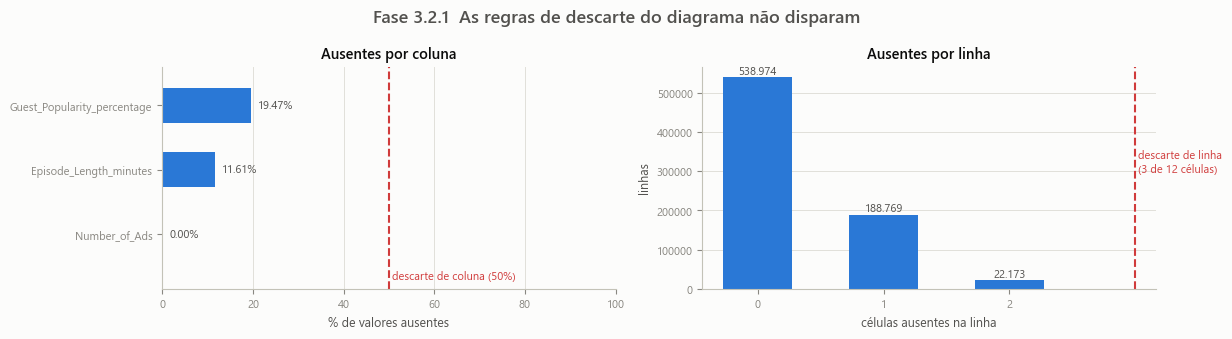

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 3.4))

com_nan = nan_coluna[nan_coluna > 0].sort_values()
pos = np.arange(len(com_nan))
ax1.barh(pos, com_nan.to_numpy(), color=SERIE_1, height=0.55)
ax1.set_yticks(pos, com_nan.index)
ax1.axvline(cfg.limite_nan_coluna, color=STATUS["critico"], linewidth=1.5, linestyle="--")
ax1.text(cfg.limite_nan_coluna, -0.75, f" descarte de coluna ({cfg.limite_nan_coluna:.0f}%)",
         color=STATUS["critico"], fontsize=8, va="bottom")
ax1.set_xlim(0, 100)
ax1.set_ylim(-0.85, len(com_nan) - 0.4)
ax1.set_xlabel("% de valores ausentes")
ax1.set_title("Ausentes por coluna")
ax1.grid(axis="y", visible=False)
for y, v in zip(pos, com_nan.to_numpy()):
    ax1.text(v + 1.5, y, f"{v:.2f}%", va="center", fontsize=8, color=TINTA_SECUNDARIA)

contagem = p_train.isna().sum(axis=1).value_counts().sort_index()
pos2 = np.arange(len(contagem))
ax2.bar(pos2, contagem.to_numpy(), color=SERIE_1, width=0.55)
ax2.set_xticks(pos2, [str(i) for i in contagem.index])
limite_celulas = 0.25 * p_train.shape[1]
ax2.axvline(limite_celulas, color=STATUS["critico"], linewidth=1.5, linestyle="--")
ax2.text(limite_celulas, contagem.max() * 0.55,
         f" descarte de linha\n ({limite_celulas:.0f} de {p_train.shape[1]} células)",
         color=STATUS["critico"], fontsize=8)
ax2.set_xlabel("células ausentes na linha")
ax2.set_ylabel("linhas")
ax2.set_title("Ausentes por linha")
ax2.grid(axis="x", visible=False)
for x, v in zip(pos2, contagem.to_numpy()):
    ax2.text(x, v, f"{v:,}".replace(",", "."), ha="center", va="bottom",
             fontsize=8, color=TINTA_SECUNDARIA)

fig.suptitle("Fase 3.2.1  As regras de descarte do diagrama não disparam",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

### 3.2.2 Estratégia por coluna categórica

In [52]:
CATEGORIA_AUSENTE = "Sem_classificacao"

COLUNAS_DESCARTAR_LINHA = ["Podcast_Name", "Episode_Title"]
COLUNAS_CATEGORIA_EXPLICITA = ["Genre", "Episode_Sentiment"]
COLUNAS_MODA_POR_GRUPO = ["Publication_Day", "Publication_Time"]
GRUPO_MODA = "Podcast_Name"


def descartar_sem_identificacao(df, colunas):
    """Remove linhas sem os campos que identificam o episódio."""
    faltando = df[colunas].isna().any(axis=1)
    return df.loc[~faltando].reset_index(drop=True), int(faltando.sum())


def marcar_categoria_ausente(df, colunas, rotulo=CATEGORIA_AUSENTE):
    """Troca NaN por uma categoria própria, em vez de imputar a moda."""
    saida = df.copy()
    n = {}
    for c in colunas:
        n[c] = int(saida[c].isna().sum())
        if n[c]:
            saida[c] = saida[c].fillna(rotulo)
    return saida, n


def ajustar_modas_por_grupo(train_df, colunas, grupo):
    """Estima, SÓ NO TRAIN, a moda de cada coluna dentro de cada grupo."""
    mapas = {}
    for c in colunas:
        por_grupo = (train_df.dropna(subset=[c])
                     .groupby(grupo)[c]
                     .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else np.nan))
        mapas[c] = {"por_grupo": por_grupo, "global": train_df[c].mode().iloc[0]}
    return mapas


def aplicar_modas_por_grupo(df, mapas, grupo):
    """Imputa pela moda do grupo; cai para a moda global se o grupo for novo."""
    saida = df.copy()
    n = {}
    for c, mapa in mapas.items():
        faltando = saida[c].isna()
        n[c] = int(faltando.sum())
        if n[c]:
            preenchido = saida.loc[faltando, grupo].map(mapa["por_grupo"]).fillna(mapa["global"])
            saida.loc[faltando, c] = preenchido
    return saida, n


p_train, n_desc_train = descartar_sem_identificacao(p_train, COLUNAS_DESCARTAR_LINHA)
p_test, n_desc_test = descartar_sem_identificacao(p_test, COLUNAS_DESCARTAR_LINHA)
registrar("3.2 NaN", f"linhas sem {' ou '.join(COLUNAS_DESCARTAR_LINHA)}", n_desc_train, n_desc_test)

p_train, n_cat_train = marcar_categoria_ausente(p_train, COLUNAS_CATEGORIA_EXPLICITA)
p_test, n_cat_test = marcar_categoria_ausente(p_test, COLUNAS_CATEGORIA_EXPLICITA)
for c in COLUNAS_CATEGORIA_EXPLICITA:
    registrar("3.2 NaN", f"{c} -> '{CATEGORIA_AUSENTE}'", n_cat_train[c], n_cat_test[c])

modas = ajustar_modas_por_grupo(p_train, COLUNAS_MODA_POR_GRUPO, GRUPO_MODA)
p_train, n_moda_train = aplicar_modas_por_grupo(p_train, modas, GRUPO_MODA)
p_test, n_moda_test = aplicar_modas_por_grupo(p_test, modas, GRUPO_MODA)
for c in COLUNAS_MODA_POR_GRUPO:
    registrar("3.2 NaN", f"{c} -> moda por {GRUPO_MODA}", n_moda_train[c], n_moda_test[c])

pd.DataFrame([
    {"coluna": " + ".join(COLUNAS_DESCARTAR_LINHA), "politica": "descartar linha",
     "aplicada_train": n_desc_train, "aplicada_test": n_desc_test},
    *[{"coluna": c, "politica": f"categoria '{CATEGORIA_AUSENTE}'",
       "aplicada_train": n_cat_train[c], "aplicada_test": n_cat_test[c]}
      for c in COLUNAS_CATEGORIA_EXPLICITA],
    *[{"coluna": c, "politica": f"moda por {GRUPO_MODA}",
       "aplicada_train": n_moda_train[c], "aplicada_test": n_moda_test[c]}
      for c in COLUNAS_MODA_POR_GRUPO],
])

,coluna,politica,aplicada_train,aplicada_test
0,Podcast_Name + Episode_Title,descartar linha,0,0
1,Genre,categoria 'Sem_classificacao',0,0
2,Episode_Sentiment,categoria 'Sem_classificacao',0,0
3,Publication_Day,moda por Podcast_Name,0,0
4,Publication_Time,moda por Podcast_Name,0,0


In [54]:
linhas_moda = []
for c in COLUNAS_MODA_POR_GRUPO:
    moda_global = p_train[c].mode().iloc[0]
    por_grupo = modas[c]["por_grupo"]
    acerto_global = (p_train[c] == moda_global).mean()
    acerto_grupo = (p_train[c] == p_train[GRUPO_MODA].map(por_grupo)).mean()
    tabela = pd.crosstab(p_train[GRUPO_MODA], p_train[c])
    qui2 = stats.chi2_contingency(tabela)
    cramer_v = np.sqrt(qui2.statistic / (tabela.to_numpy().sum() * (min(tabela.shape) - 1)))
    linhas_moda.append({
        "coluna": c,
        "n_categorias": p_train[c].nunique(),
        "moda_global": moda_global,
        "modas_distintas_entre_podcasts": int(por_grupo.nunique()),
        "acerto_moda_global_pct": round(100 * acerto_global, 2),
        "acerto_moda_por_podcast_pct": round(100 * acerto_grupo, 2),
        "ganho_pp": round(100 * (acerto_grupo - acerto_global), 2),
        "cramer_v": round(float(cramer_v), 4),
    })

display(pd.DataFrame(linhas_moda))

print("Leitura: o V de Cramér mede a associação entre o podcast e o dia/horário de\n"
      "publicação (0 = independentes, 1 = determinado). Os dois ficam em ~0,02:\n"
      "os programas publicam em dias e horários praticamente aleatórios.\n\n"
      "Consequência: a moda por podcast acerta menos de 1 ponto percentual a mais\n"
      "que a moda global. A regra é a política correta - só não há estrutura neste\n"
      "dataset para ela explorar. Mantida por custar nada e proteger de outro dataset.")

,coluna,n_categorias,moda_global,modas_distintas_entre_podcasts,acerto_moda_global_pct,acerto_moda_por_podcast_pct,ganho_pp,cramer_v
0,Publication_Day,7,Sunday,6,15.4600,15.7700,0.3100,0.0206
1,Publication_Time,4,Night,4,26.2500,26.9100,0.6600,0.0229


Leitura: o V de Cramér mede a associação entre o podcast e o dia/horário de
publicação (0 = independentes, 1 = determinado). Os dois ficam em ~0,02:
os programas publicam em dias e horários praticamente aleatórios.

Consequência: a moda por podcast acerta menos de 1 ponto percentual a mais
que a moda global. A regra é a política correta - só não há estrutura neste
dataset para ela explorar. Mantida por custar nada e proteger de outro dataset.


### 3.2.3 As duas colunas numéricas com ausentes

`Episode_Length_minutes` (11,6%) é a variável mais preditiva do dataset Pearson
0,917 com o alvo. `Guest_Popularity_percentage` (19,5%) é a que mais falta.

In [49]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import KNNImputer

NUMERICAS_ORIGINAIS = ["Episode_Length_minutes", "Host_Popularity_percentage",
                       "Guest_Popularity_percentage", "Number_of_Ads"]
CATEGORICAS_PARA_MODELO = ["Genre", "Publication_Day", "Publication_Time", "Episode_Sentiment"]


def comparar_imputacoes(df, coluna, n_amostra=60_000, semente=42):
    """Mede o erro de cada estratégia de imputação escondendo valores conhecidos."""
    gerador = np.random.default_rng(semente)
    taxa = df[coluna].isna().mean()
    base = (df[df[coluna].notna()]
            .sample(n=min(n_amostra, int(df[coluna].notna().sum())), random_state=semente)
            .reset_index(drop=True))
    mascara = gerador.random(len(base)) < taxa
    verdade = base.loc[mascara, coluna].to_numpy()
    observado = base[coluna].mask(mascara)
    resultados = []

    def medir(nome, previsto):
        previsto = np.asarray(previsto, dtype=float)
        resultados.append({
            "estrategia": nome,
            "rmse": float(np.sqrt(np.mean((previsto - verdade) ** 2))),
            "mae": float(np.mean(np.abs(previsto - verdade))),
        })

    medir("média global", np.full(mascara.sum(), observado.mean()))
    medir("mediana global", np.full(mascara.sum(), observado.median()))
    for grupo in ["Podcast_Name", "Genre", "Episode_Title", "Publication_Time"]:
        medianas = observado.groupby(base[grupo]).median()
        medir(f"mediana por {grupo}",
              base.loc[mascara, grupo].map(medianas).fillna(observado.median()))

    # KNN sobre as numéricas. O fit é numa subamostra: KNNImputer é O(n^2) e não
    # roda em 663 mil linhas em tempo viável - o que já é, por si, um argumento.
    matriz = base[NUMERICAS_ORIGINAIS].copy()
    matriz[coluna] = observado
    knn = KNNImputer(n_neighbors=5).fit(matriz.sample(n=8_000, random_state=1))
    imputada = pd.DataFrame(knn.transform(matriz), columns=NUMERICAS_ORIGINAIS, index=matriz.index)
    medir("KNNImputer (k=5)", imputada.loc[mascara, coluna])

    # Regressão sobre todas as outras colunas, sem o alvo.
    preditoras = [c for c in NUMERICAS_ORIGINAIS if c != coluna]
    X = pd.concat([base[preditoras], base[CATEGORICAS_PARA_MODELO].astype("category")], axis=1)
    eh_cat = [c in CATEGORICAS_PARA_MODELO for c in X.columns]
    modelo = HistGradientBoostingRegressor(max_iter=120, random_state=0, categorical_features=eh_cat)
    modelo.fit(X[~mascara], observado[~mascara])
    medir("regressão (HistGB), sem o alvo", modelo.predict(X[mascara]))

    # Só para dimensionar o teto: a mesma regressão COM o alvo entre as preditoras.
    # É inutilizável (o test não tem alvo), mas mostra onde estaria a informação.
    X_alvo = X.copy()
    X_alvo[cfg.target] = base[cfg.target]
    modelo_alvo = HistGradientBoostingRegressor(
        max_iter=120, random_state=0,
        categorical_features=[c in CATEGORICAS_PARA_MODELO for c in X_alvo.columns])
    modelo_alvo.fit(X_alvo[~mascara], observado[~mascara])
    medir("regressão COM o alvo (inviável no test)", modelo_alvo.predict(X_alvo[mascara]))

    saida = pd.DataFrame(resultados).sort_values("rmse").reset_index(drop=True)
    saida.insert(1, "desvio_padrao_da_coluna", observado.std())
    saida["rmse_sobre_desvio"] = (saida["rmse"] / observado.std()).round(4)
    return saida


bench_length = comparar_imputacoes(p_train, "Episode_Length_minutes")
bench_guest = comparar_imputacoes(p_train, "Guest_Popularity_percentage")

print("Episode_Length_minutes")
display(bench_length)
print("Guest_Popularity_percentage")
display(bench_guest)

Episode_Length_minutes


,estrategia,desvio_padrao_da_coluna,rmse,mae,rmse_sobre_desvio
0,regressão COM o alvo (inviável no test),32.8775,11.6740,9.1039,0.3551
1,"regressão (HistGB), sem o alvo",32.8775,32.7684,28.3571,0.9967
2,mediana por Podcast_Name,32.8775,32.9074,28.4929,1.0009
3,média global,32.8775,32.9187,28.5157,1.0013
4,mediana por Publication_Time,32.8775,32.9240,28.4999,1.0014
5,mediana global,32.8775,32.9258,28.5104,1.0015
6,mediana por Genre,32.8775,32.9273,28.5145,1.0015
7,mediana por Episode_Title,32.8775,33.0289,28.5267,1.0046
8,KNNImputer (k=5),32.8775,35.8676,30.2490,1.0909


Guest_Popularity_percentage


,estrategia,desvio_padrao_da_coluna,rmse,mae,rmse_sobre_desvio
0,regressão COM o alvo (inviável no test),28.4939,28.5295,24.5405,1.0013
1,"regressão (HistGB), sem o alvo",28.4939,28.5348,24.5688,1.0014
2,mediana por Genre,28.4939,28.5488,24.5402,1.0019
3,média global,28.4939,28.5556,24.6002,1.0022
4,mediana por Podcast_Name,28.4939,28.5636,24.5370,1.0024
5,mediana global,28.4939,28.5670,24.5586,1.0026
6,mediana por Publication_Time,28.4939,28.5687,24.5579,1.0026
7,mediana por Episode_Title,28.4939,28.6018,24.5433,1.0038
8,KNNImputer (k=5),28.4939,31.0889,26.1620,1.0911


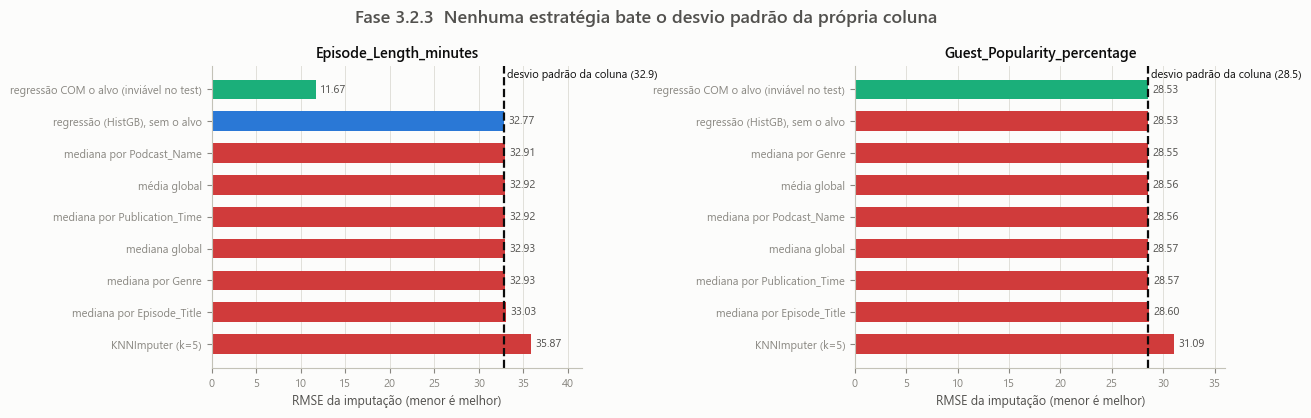

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

for ax, (bench, coluna) in zip(axes, [(bench_length, "Episode_Length_minutes"),
                                      (bench_guest, "Guest_Popularity_percentage")]):
    ordenado = bench.sort_values("rmse", ascending=False).reset_index(drop=True)
    pos = np.arange(len(ordenado))
    desvio = ordenado["desvio_padrao_da_coluna"].iloc[0]
    cores = [SERIE_3 if "COM o alvo" in e else (STATUS["critico"] if r > desvio else SERIE_1)
             for e, r in zip(ordenado["estrategia"], ordenado["rmse"])]
    ax.barh(pos, ordenado["rmse"], color=cores, height=0.62)
    ax.set_yticks(pos, ordenado["estrategia"])
    ax.axvline(desvio, color=TINTA_PRIMARIA, linewidth=1.6, linestyle="--")
    ax.text(desvio, len(ordenado) - 0.35, f" desvio padrão da coluna ({desvio:.1f})",
            fontsize=8, color=TINTA_PRIMARIA, va="top")
    ax.set_xlabel("RMSE da imputação (menor é melhor)")
    ax.set_title(coluna)
    ax.grid(axis="y", visible=False)
    for y, v in zip(pos, ordenado["rmse"]):
        ax.text(v + desvio * 0.015, y, f"{v:.2f}", va="center", fontsize=8, color=TINTA_SECUNDARIA)
    ax.set_xlim(0, ordenado["rmse"].max() * 1.16)

fig.suptitle("Fase 3.2.3  Nenhuma estratégia bate o desvio padrão da própria coluna",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

In [86]:
completos = p_train[p_train["Episode_Length_minutes"].notna()]
X_completo = completos[["Episode_Length_minutes"]]
r2_completos = LinearRegression().fit(X_completo, completos[cfg.target]).score(
    X_completo, completos[cfg.target])

teste_flag = p_train.copy()
teste_flag["_L"] = teste_flag["Episode_Length_minutes"].fillna(
    teste_flag["Episode_Length_minutes"].median())
teste_flag["_ausente"] = teste_flag["Episode_Length_minutes"].isna().astype(int)
r2_mediana = LinearRegression().fit(teste_flag[["_L"]], teste_flag[cfg.target]).score(
    teste_flag[["_L"]], teste_flag[cfg.target])
r2_mediana_flag = LinearRegression().fit(teste_flag[["_L", "_ausente"]], teste_flag[cfg.target]).score(
    teste_flag[["_L", "_ausente"]], teste_flag[cfg.target])

ausentes = teste_flag[teste_flag["_ausente"] == 1]
presentes = teste_flag[teste_flag["_ausente"] == 0]
t_stat, p_valor = stats.ttest_ind(ausentes[cfg.target], presentes[cfg.target], equal_var=False)

display(pd.DataFrame([
    {"cenario": "só casos completos (Episode_Length observada)", "n": len(completos), "r2": r2_completos},
    {"cenario": "todas as linhas, imputação pela mediana", "n": len(teste_flag), "r2": r2_mediana},
    {"cenario": "todas as linhas, mediana + flag de ausência", "n": len(teste_flag), "r2": r2_mediana_flag},
]))

print(f"Custo da imputação: {r2_completos:.4f} -> {r2_mediana:.4f}  "
      f"({100 * (r2_completos - r2_mediana):.1f} pontos de R²)\n")
print("A ausência NÃO é aleatória (não é MCAR):")
print(f"  alvo médio quando Episode_Length está ausente:  {ausentes[cfg.target].mean():.2f} min")
print(f"  alvo médio quando está presente:                {presentes[cfg.target].mean():.2f} min")
print(f"  teste t de Welch: t = {t_stat:.1f}, p = {p_valor:.2e}")
print("\nComo a ausência carrega sinal, ela vira uma variável explícita na 3.4.")

,cenario,n,r2
0,só casos completos (Episode_Length observada),662822,0.8410
1,"todas as linhas, imputação pela mediana",749916,0.7508
2,"todas as linhas, mediana + flag de ausência",749916,0.7514


Custo da imputação: 0.8410 -> 0.7508  (9.0 pontos de R²)

A ausência NÃO é aleatória (não é MCAR):
  alvo médio quando Episode_Length está ausente:  43.15 min
  alvo médio quando está presente:                45.73 min
  teste t de Welch: t = -27.4, p = 8.18e-165

Como a ausência carrega sinal, ela vira uma variável explícita na 3.4.


In [88]:
MEDIANAS = {c: float(p_train[c].median())
            for c in ["Episode_Length_minutes", "Guest_Popularity_percentage", "Number_of_Ads"]}

# As flags são criadas ANTES de imputar - depois a informação some.
for df in (p_train, p_test):
    df["Length_Ausente"] = df["Episode_Length_minutes"].isna().astype("int8")
    df["Sem_Convidado"] = df["Guest_Popularity_percentage"].isna().astype("int8")

n_imputados = {}
for coluna, valor in MEDIANAS.items():
    n_imputados[coluna] = (int(p_train[coluna].isna().sum()), int(p_test[coluna].isna().sum()))
    p_train[coluna] = p_train[coluna].fillna(valor)
    p_test[coluna] = p_test[coluna].fillna(valor)
    registrar("3.2 NaN", f"{coluna} -> mediana do train ({valor:.2f})", *n_imputados[coluna])

display(pd.DataFrame([
    {"coluna": c, "mediana_do_train": v,
     "imputados_train": n_imputados[c][0], "imputados_test": n_imputados[c][1]}
    for c, v in MEDIANAS.items()
]))

print("NaN restantes  train:", int(p_train.isna().sum().sum()),
      "| test:", int(p_test.isna().sum().sum()))

,coluna,mediana_do_train,imputados_train,imputados_test
0,Episode_Length_minutes,63.8400,87094,28736
1,Guest_Popularity_percentage,53.5800,146020,48832
2,Number_of_Ads,1.0000,1,0


NaN restantes  train: 233114 | test: 77568


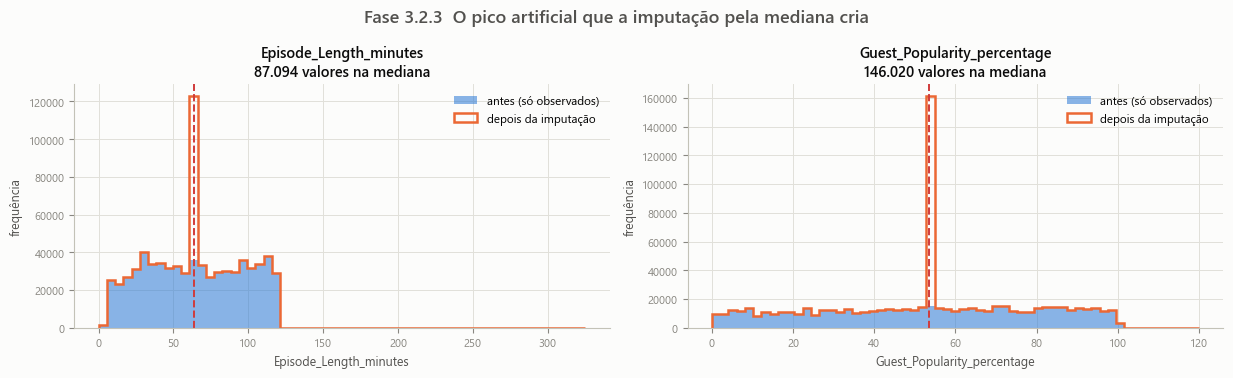

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 3.8))
for ax, coluna in zip(axes, ["Episode_Length_minutes", "Guest_Popularity_percentage"]):
    original = train[coluna].dropna()
    faixas = np.linspace(original.min(), original.max(), 60)
    ax.hist(original, bins=faixas, color=SERIE_1, alpha=0.55, edgecolor="none",
            label="antes (só observados)")
    ax.hist(p_train[coluna], bins=faixas, histtype="step", color=SERIE_2, linewidth=1.8,
            label="depois da imputação")
    ax.axvline(MEDIANAS[coluna], color=STATUS["critico"], linewidth=1.4, linestyle="--")
    ax.set_title(f"{coluna}\n{n_imputados[coluna][0]:,} valores na mediana".replace(",", "."))
    ax.set_xlabel(coluna)
    ax.set_ylabel("frequência")
    ax.legend()
fig.suptitle("Fase 3.2.3  O pico artificial que a imputação pela mediana cria",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

O pico na linha vermelha é o efeito colateral da mediana: 87 mil episódios passam a
ter exatamente a mesma duração. É a representação visual dos 9 pontos de R² perdidos
— e o motivo pelo qual a flag Length_Ausente precisa existir.

## 3.3 Tratamento de outliers estatísticos

Bloco `IQR clipping · winsorization · z-score > 3` do diagrama. A Fase 2.3 já
antecipou o resultado: com distribuições quase uniformes, os limites do IQR caem
fora do alcance das variáveis. Vale executar para registrar o quanto.

Os limites são ajustados **só no train** (`ajustar_limites`) e aplicados sem
recálculo ao `test` (`aplicar_limites`), ambos do módulo `Pipeline.eda.fase3_outliers`.

In [57]:
METODO_POR_COLUNA = {c: "iqr" for c in NUMERICAS_ORIGINAIS}

limites = ajustar_limites(p_train, METODO_POR_COLUNA, k_iqr=1.5)

antes_outliers = p_train.copy()
p_train, afetados_train = aplicar_limites(p_train, limites)
p_test, afetados_test = aplicar_limites(p_test, limites)

resumo_outliers = (
    limites
    .merge(afetados_train.rename(columns={"n_afetados": "n_train", "pct_afetados": "pct_train"}), on="coluna")
    .merge(afetados_test.rename(columns={"n_afetados": "n_test", "pct_afetados": "pct_test"}), on="coluna")
)
resumo_outliers["max_observado_train"] = [antes_outliers[c].max() for c in resumo_outliers["coluna"]]
for _, r in resumo_outliers.iterrows():
    registrar("3.3 outliers", f"{r['coluna']} recortada em [{r['limite_inf']:.2f}, {r['limite_sup']:.2f}] ({r['metodo']})",
              int(r["n_train"]), int(r["n_test"]))
resumo_outliers

,coluna,metodo,limite_inf,limite_sup,n_train,pct_train,n_test,pct_test,max_observado_train
0,Episode_Length_minutes,iqr,-36.8900,166.6300,1,0.0001,2,0.0008,325.2400
1,Host_Popularity_percentage,iqr,-20.7700,139.7100,0,0.0000,0,0.0000,100.0000
2,Guest_Popularity_percentage,iqr,-20.1850,125.7750,0,0.0000,0,0.0000,100.0000
3,Number_of_Ads,iqr,-3.0000,5.0000,0,0.0000,0,0.0000,3.0000


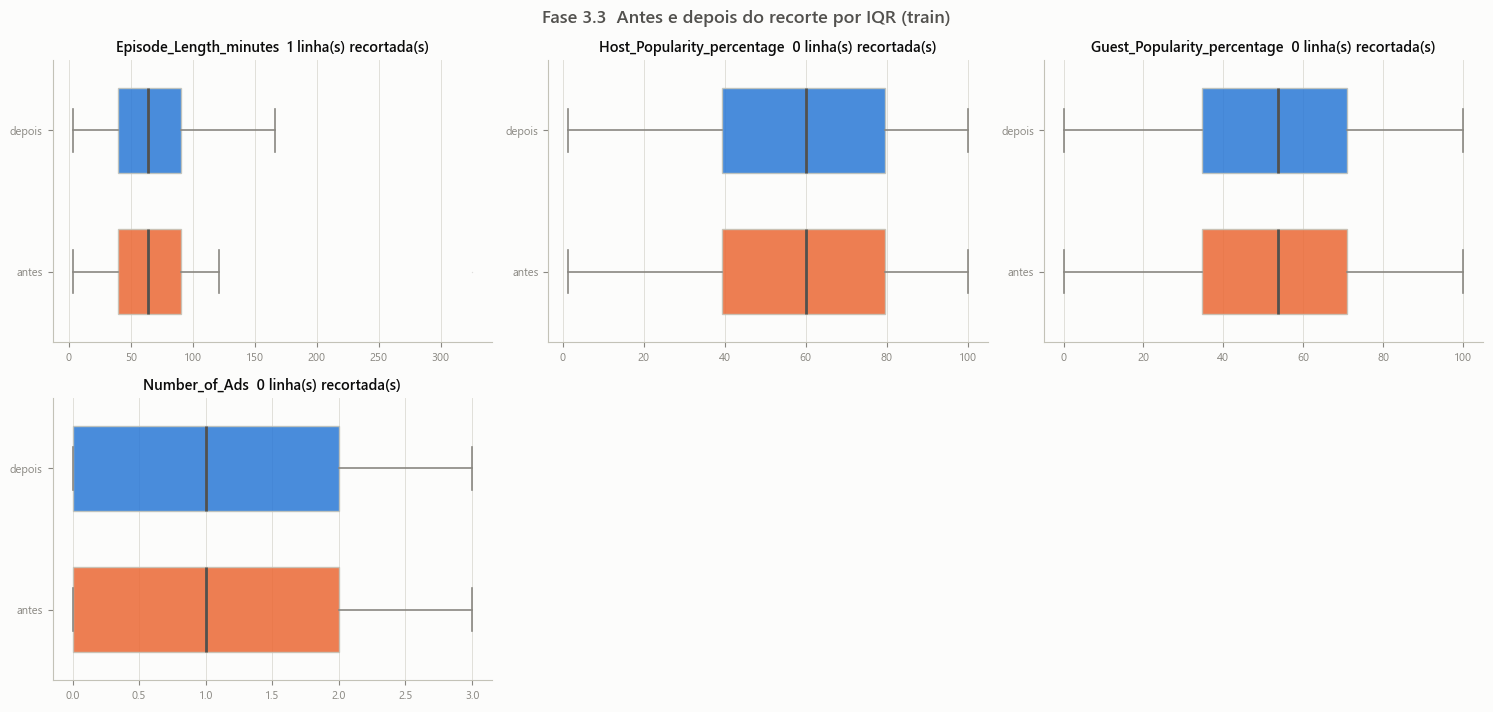

In [58]:
fig, axes = grade_de_paineis(len(NUMERICAS_ORIGINAIS), cfg)
for ax, coluna in zip(axes, NUMERICAS_ORIGINAIS):
    caixa = ax.boxplot([antes_outliers[coluna].dropna(), p_train[coluna].dropna()],
                       vert=False, widths=0.6, patch_artist=True,
                       tick_labels=["antes", "depois"],
                       flierprops={"marker": ".", "markersize": 2,
                                   "markerfacecolor": TINTA_SUAVE,
                                   "markeredgecolor": "none", "alpha": 0.25})
    for artista, cor in zip(caixa["boxes"], (SERIE_2, SERIE_1)):
        artista.set(facecolor=cor, edgecolor=EIXO, alpha=0.85)
    for elemento in ("whiskers", "caps"):
        for artista in caixa[elemento]:
            artista.set(color=TINTA_SUAVE, linewidth=1.2)
    for mediana in caixa["medians"]:
        mediana.set(color=TINTA_SECUNDARIA, linewidth=2.0)
    n = int(resumo_outliers.loc[resumo_outliers["coluna"] == coluna, "n_train"].iloc[0])
    ax.set_title(f"{coluna}  {n} linha(s) recortada(s)")
    ax.grid(axis="y", visible=False)
fig.suptitle("Fase 3.3  Antes e depois do recorte por IQR (train)",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

## 3.4 Engenharia de features

No diagrama esta caixa aparece na Fase 2 (`Is_Weekend · interações Length×Host_Pop`),
mas ela **transforma** os dados, então pertence à Fase 3 — a Fase 2 foi mantida
puramente descritiva de propósito.

Candidatas, e a hipótese por trás de cada uma:

| feature | definição | hipótese |
|---|---|---|
| `Episode_Num` | inteiro extraído de `Episode_Title` | a Fase 2.4 notou que o "texto" é `Episode N`, com N de 1 a 100: é um número disfarçado, e 1 coluna substitui 100 |
| `Is_Weekend` | publicação em sábado ou domingo | do diagrama; hábito de consumo muda no fim de semana |
| `Ads_por_minuto` | `Number_of_Ads / Episode_Length_minutes` | densidade de interrupção importa mais que a contagem absoluta |
| `Length_x_Host_Pop` | `Episode_Length × Host_Popularity` | do diagrama; episódio longo de host popular seria diferente de episódio longo de host obscuro |
| `Length_Ausente` | duração não registrada | a 3.2.3 provou que a ausência tem sinal (p ≈ 2e−165) |
| `Sem_Convidado` | popularidade de convidado ausente | a ausência provavelmente significa "episódio sem convidado" |
| `Publication_Time_ord` | Morning<Afternoon<Evening<Night | o horário tem ordem natural; ordinal em vez de 4 dummies |
| `Sentimento_ord` | Negative<Neutral<Positive | idem, com ordem de valência |
| `Pop_Media`, `Pop_Diferenca` | média e diferença das popularidades | resumir as duas colunas de popularidade |

In [89]:
ORDEM_HORARIO = {"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3}
ORDEM_SENTIMENTO = {"Negative": 0, "Neutral": 1, "Positive": 2}
FIM_DE_SEMANA = ["Saturday", "Sunday"]


def engenharia_de_features(df):
    """Cria as features derivadas. Não depende de nenhum parâmetro do train,
    então pode ser aplicada a train e test com o mesmo código e sem vazamento."""
    saida = df.copy()
    duracao = saida["Episode_Length_minutes"]

    saida["Episode_Num"] = saida["Episode_Title"].str.extract(r"(\d+)")[0].astype("int16")
    saida["Is_Weekend"] = saida["Publication_Day"].isin(FIM_DE_SEMANA).astype("int8")
    saida["Ads_por_minuto"] = saida["Number_of_Ads"] / duracao.replace(0, np.nan)
    saida["Length_x_Host_Pop"] = duracao * saida["Host_Popularity_percentage"]
    saida["Pop_Media"] = saida[["Host_Popularity_percentage", "Guest_Popularity_percentage"]].mean(axis=1)
    saida["Pop_Diferenca"] = saida["Host_Popularity_percentage"] - saida["Guest_Popularity_percentage"]
    # -1 para categorias que não existiam no train (inclusive 'Sem_classificacao').
    saida["Publication_Time_ord"] = saida["Publication_Time"].map(ORDEM_HORARIO).fillna(-1).astype("int8")
    saida["Sentimento_ord"] = saida["Episode_Sentiment"].map(ORDEM_SENTIMENTO).fillna(-1).astype("int8")
    return saida


p_train = engenharia_de_features(p_train)
p_test = engenharia_de_features(p_test)

# Ads_por_minuto fica NaN se a duração for 0; a 3.1 removeu esse caso, mas a
# guarda continua para o test.
mediana_ads_min = float(p_train["Ads_por_minuto"].median())
p_train["Ads_por_minuto"] = p_train["Ads_por_minuto"].fillna(mediana_ads_min)
p_test["Ads_por_minuto"] = p_test["Ads_por_minuto"].fillna(mediana_ads_min)

NOVAS_FEATURES = ["Episode_Num", "Is_Weekend", "Ads_por_minuto", "Length_x_Host_Pop",
                  "Pop_Media", "Pop_Diferenca", "Publication_Time_ord", "Sentimento_ord",
                  "Length_Ausente", "Sem_Convidado"]
registrar("3.4 features", f"{len(NOVAS_FEATURES)} features derivadas criadas",
          len(NOVAS_FEATURES), len(NOVAS_FEATURES), ", ".join(NOVAS_FEATURES))

print(f"p_train: {p_train.shape[1]} colunas | p_test: {p_test.shape[1]} colunas")
p_train[NOVAS_FEATURES].head()

p_train: 22 colunas | p_test: 21 colunas


,Episode_Num,Is_Weekend,Ads_por_minuto,Length_x_Host_Pop,Pop_Media,Pop_Diferenca,Publication_Time_ord,Sentimento_ord,Length_Ausente,Sem_Convidado
0,98,0,0.0000,"4,775.8704",64.1950,21.2300,3,2,1,1
1,26,1,0.0167,"8,020.6100",71.4500,-9.0000,1,0,0,0
2,16,0,0.0000,"5,170.7830",39.4700,61.0000,2,0,0,0
3,45,0,0.0298,"3,843.4674",67.9600,-21.4800,0,2,0,0
4,86,0,0.0271,"8,848.5357",69.3750,21.3900,1,1,0,0


### Cada feature nova serve para alguma coisa?

Duas medidas, e elas discordam de propósito:

- **Correlação com o alvo:** o quanto a feature se move junto com o alvo, sozinha.
- **Ganho de R²:** o quanto ela acrescenta a um modelo linear que **já tem** as
  quatro numéricas originais. É a medida que importa, porque uma feature derivada
  de `Episode_Length` herda a correlação dela sem trazer nada de novo.

In [59]:
BASE_R2 = NUMERICAS_ORIGINAIS
y_aval = p_train[cfg.target].to_numpy()
r2_base = LinearRegression().fit(p_train[BASE_R2], y_aval).score(p_train[BASE_R2], y_aval)

linhas_features = []
for coluna in NOVAS_FEATURES:
    r2_com = LinearRegression().fit(p_train[BASE_R2 + [coluna]], y_aval).score(
        p_train[BASE_R2 + [coluna]], y_aval)
    linhas_features.append({
        "feature": coluna,
        "pearson_vs_alvo": p_train[coluna].corr(p_train[cfg.target]),
        "spearman_vs_alvo": p_train[coluna].corr(p_train[cfg.target], method="spearman"),
        "r2_com_a_feature": r2_com,
        "ganho_de_r2": r2_com - r2_base,
    })

avaliacao_features = (pd.DataFrame(linhas_features)
                      .sort_values("ganho_de_r2", ascending=False)
                      .reset_index(drop=True))

r2_todas = LinearRegression().fit(p_train[BASE_R2 + NOVAS_FEATURES], y_aval).score(
    p_train[BASE_R2 + NOVAS_FEATURES], y_aval)

print(f"R² da baseline (4 numéricas originais): {r2_base:.6f}")
print(f"R² com todas as {len(NOVAS_FEATURES)} features novas:     {r2_todas:.6f}  "
      f"(ganho {r2_todas - r2_base:+.6f})")
avaliacao_features

R² da baseline (4 numéricas originais): 0.757694
R² com todas as 10 features novas:     0.759685  (ganho +0.001990)


,feature,pearson_vs_alvo,spearman_vs_alvo,r2_com_a_feature,ganho_de_r2
0,Ads_por_minuto,-0.4517,-0.4280,0.7585,0.0008
1,Length_Ausente,-0.0305,-0.0292,0.7583,0.0006
2,Length_x_Host_Pop,0.6781,0.7041,0.7581,0.0004
3,Sentimento_ord,0.0394,0.0371,0.7580,0.0003
4,Sem_Convidado,-0.0028,-0.0008,0.7577,0.0000
5,Publication_Time_ord,0.0155,0.0173,0.7577,0.0000
6,Episode_Num,-0.0174,-0.0218,0.7577,0.0000
7,Is_Weekend,-0.0090,-0.0100,0.7577,0.0000
8,Pop_Diferenca,0.0451,0.0405,0.7577,0.0000
9,Pop_Media,0.0230,0.0199,0.7577,0.0000


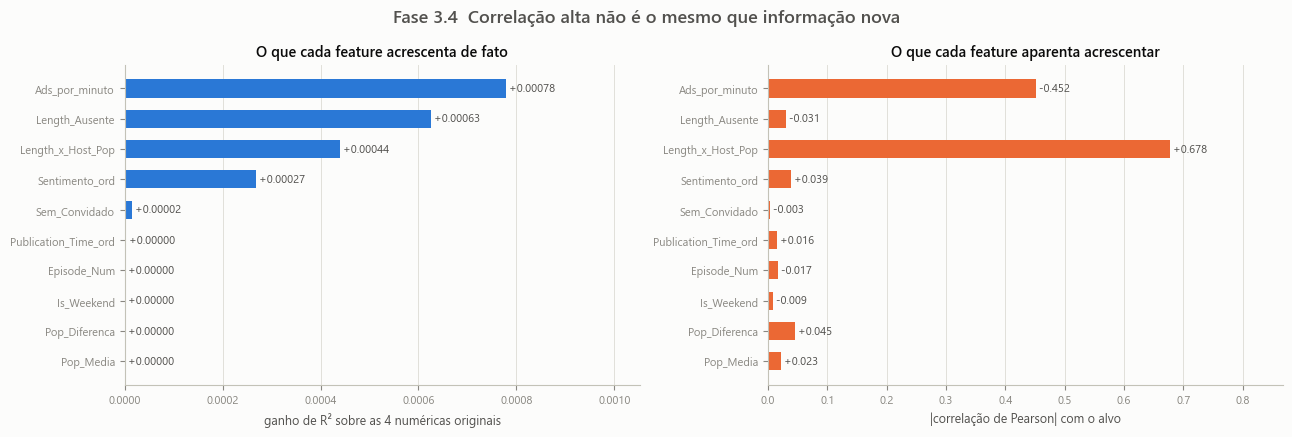

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

ordenado = avaliacao_features.sort_values("ganho_de_r2")
pos = np.arange(len(ordenado))
ax1.barh(pos, ordenado["ganho_de_r2"], color=SERIE_1, height=0.6)
ax1.set_yticks(pos, ordenado["feature"])
ax1.set_xlabel("ganho de R² sobre as 4 numéricas originais")
ax1.set_title("O que cada feature acrescenta de fato")
ax1.grid(axis="y", visible=False)
for y, v in zip(pos, ordenado["ganho_de_r2"]):
    ax1.text(v, y, f" {v:+.5f}", va="center", fontsize=8, color=TINTA_SECUNDARIA)
ax1.set_xlim(0, ordenado["ganho_de_r2"].max() * 1.35)

pos2 = np.arange(len(ordenado))
ax2.barh(pos2, ordenado["pearson_vs_alvo"].abs(), color=SERIE_2, height=0.6)
ax2.set_yticks(pos2, ordenado["feature"])
ax2.set_xlabel("|correlação de Pearson| com o alvo")
ax2.set_title("O que cada feature aparenta acrescentar")
ax2.grid(axis="y", visible=False)
for y, v in zip(pos2, ordenado["pearson_vs_alvo"]):
    ax2.text(abs(v), y, f" {v:+.3f}", va="center", fontsize=8, color=TINTA_SECUNDARIA)
ax2.set_xlim(0, ordenado["pearson_vs_alvo"].abs().max() * 1.28)

fig.suptitle("Fase 3.4  Correlação alta não é o mesmo que informação nova",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

### O efeito dos anúncios sobre a fração escutada

A Fase 2 conjecturou que os anúncios teriam efeito **não linear** sobre a fração
escutada, e que isso seria o ganho dos modelos de árvore. Dá para testar direto.

,Number_of_Ads,n,media,mediana,desvio,queda_vs_zero_pp
0,0.0000,217550,0.7065,0.7344,0.2076,0.0000
1,1.0000,214049,0.6837,0.7145,0.2203,-2.2800
2,2.0000,158141,0.6570,0.6761,0.2083,-4.9600
3,3.0000,160176,0.6282,0.6393,0.2017,-7.8300


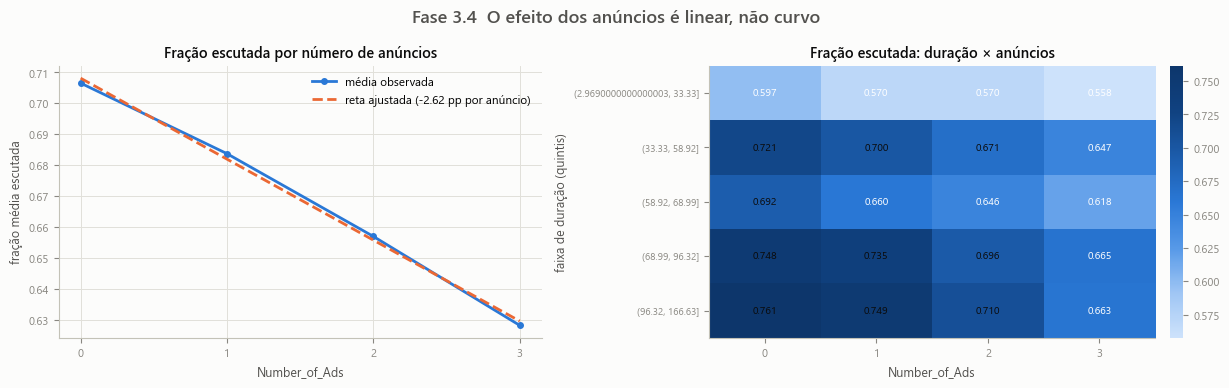

In [62]:
fracao = p_train[p_train["Episode_Length_minutes"] > 0].copy()
fracao["fracao_escutada"] = (fracao[cfg.target] / fracao["Episode_Length_minutes"]).clip(0, 1)
perfil_ads = (fracao.groupby("Number_of_Ads")["fracao_escutada"]
              .agg(n="count", media="mean", mediana="median", desvio="std")
              .reset_index())
perfil_ads["queda_vs_zero_pp"] = (
    100 * (perfil_ads["media"] - perfil_ads.loc[0, "media"])).round(2)
display(perfil_ads)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.4, 3.9))

ax1.plot(perfil_ads["Number_of_Ads"], perfil_ads["media"], color=SERIE_1,
         marker="o", label="média observada")
ajuste = np.polyfit(perfil_ads["Number_of_Ads"], perfil_ads["media"], 1)
ax1.plot(perfil_ads["Number_of_Ads"], np.polyval(ajuste, perfil_ads["Number_of_Ads"]),
         color=SERIE_2, linestyle="--",
         label=f"reta ajustada ({ajuste[0]*100:+.2f} pp por anúncio)")
ax1.set_xticks(perfil_ads["Number_of_Ads"])
ax1.set_xlabel("Number_of_Ads")
ax1.set_ylabel("fração média escutada")
ax1.set_title("Fração escutada por número de anúncios")
ax1.legend()

faixas_dur = pd.qcut(fracao["Episode_Length_minutes"], q=5, duplicates="drop")
tabela_calor = (fracao.groupby([faixas_dur, "Number_of_Ads"], observed=True)["fracao_escutada"]
                .mean().unstack())
imagem = ax2.imshow(tabela_calor.to_numpy(), cmap=SEQUENCIAL, aspect="auto")
ax2.set_xticks(range(len(tabela_calor.columns)), [f"{int(c)}" for c in tabela_calor.columns])
ax2.set_yticks(range(len(tabela_calor.index)), [str(i) for i in tabela_calor.index], fontsize=7)
ax2.set_xlabel("Number_of_Ads")
ax2.set_ylabel("faixa de duração (quintis)")
ax2.set_title("Fração escutada: duração × anúncios")
ax2.grid(visible=False)
for i in range(tabela_calor.shape[0]):
    for j in range(tabela_calor.shape[1]):
        v = tabela_calor.iat[i, j]
        ax2.text(j, i, f"{v:.3f}", ha="center", va="center", fontsize=7.5,
                 color="#ffffff" if v < tabela_calor.to_numpy().mean() else TINTA_PRIMARIA)
fig.colorbar(imagem, ax=ax2, fraction=0.046, pad=0.03).outline.set_visible(False)

fig.suptitle("Fase 3.4  O efeito dos anúncios é linear, não curvo",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**A conjectura da Fase 2 se confirma só de leve.** Cada anúncio derruba a fração
escutada em ~2,6 pontos percentuais e os quatro pontos ficam quase sobre a reta. Há
uma curvatura, mas é pequena: a queda do primeiro anúncio é de 2,28 pp, a do
segundo 2,68 pp e a do terceiro 2,87 pp. O efeito **acelera**, e uma árvore
consegue capturar isso — só que o prêmio é da ordem de 0,6 pp de fração escutada,
não o ganho substancial que a Fase 2 imaginava.

O mapa de calor acrescenta a segunda metade da resposta: o efeito é estável ao
longo das faixas de duração. As linhas caem juntas, sem interação relevante entre
duração e anúncios — que era exatamente a não linearidade que valeria a pena.

Isso reduz a expectativa de ganho das árvores sobre a regressão linear. A Fase 4
deve medir o baseline linear primeiro e exigir dos modelos mais caros uma melhora
que justifique o custo.

## 3.5 Encoding de variáveis categóricas

O diagrama pede `Ordinal (Pub_Time) · OHE (Genre, Day)`. Restam três decisões que
ele não cobre: `Episode_Sentiment` (já resolvido como ordinal na 3.4),
`Podcast_Name` (48 níveis) e `Episode_Title` (100 níveis).

A Fase 2.4 mostrou que **nenhuma** categórica passa de η² = 0,0058 — menos de 0,6%
da variância. Gastar 148 colunas de One-Hot com `Podcast_Name` + `Episode_Title`
para capturar isso é caro. A alternativa é **target encoding**: substituir a
categoria pela média do alvo naquela categoria, em 1 coluna.

O risco do target encoding é vazamento — a média inclui a própria linha. O
`TargetEncoder` do scikit-learn resolve isso com validação cruzada interna: no
`fit_transform` cada linha recebe a média calculada **sem ela**, e o `transform`
do `test` usa as médias do train inteiro.

In [63]:
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

COLUNAS_OHE = ["Genre", "Publication_Day"]
COLUNAS_TARGET_ENCODING = ["Podcast_Name", "Episode_Title"]

# --- One-Hot: drop="first" evita a armadilha das dummies na regressão linear.
ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore", dtype=np.int8)
ohe_train = ohe.fit_transform(p_train[COLUNAS_OHE])
ohe_test = ohe.transform(p_test[COLUNAS_OHE])
nomes_ohe = list(ohe.get_feature_names_out(COLUNAS_OHE))

# --- Target encoding com validação cruzada interna (fit apenas no train).
te = TargetEncoder(target_type="continuous", cv=5, random_state=cfg.random_state)
te_train = te.fit_transform(p_train[COLUNAS_TARGET_ENCODING], p_train[cfg.target])
te_test = te.transform(p_test[COLUNAS_TARGET_ENCODING])
nomes_te = [f"{c}_te" for c in COLUNAS_TARGET_ENCODING]

for nome, valores in zip(nomes_ohe, ohe_train.T):
    p_train[nome] = valores
for nome, valores in zip(nomes_ohe, ohe_test.T):
    p_test[nome] = valores
for i, nome in enumerate(nomes_te):
    p_train[nome] = te_train[:, i]
    p_test[nome] = te_test[:, i]

registrar("3.5 encoding", f"One-Hot em {', '.join(COLUNAS_OHE)}", len(nomes_ohe), len(nomes_ohe))
registrar("3.5 encoding", f"target encoding em {', '.join(COLUNAS_TARGET_ENCODING)}",
          len(nomes_te), len(nomes_te))

comparacao_encoding = pd.DataFrame([
    {
        "coluna": c,
        "n_categorias": int(p_train[c].nunique()),
        "estrategia": "target encoding",
        "colunas_geradas": 1,
        "colunas_se_fosse_ohe": int(p_train[c].nunique()) - 1,
        "corr_com_alvo": p_train[f"{c}_te"].corr(p_train[cfg.target]),
        "amplitude_min": p_train[f"{c}_te"].max() - p_train[f"{c}_te"].min(),
    }
    for c in COLUNAS_TARGET_ENCODING
] + [
    {
        "coluna": c,
        "n_categorias": int(p_train[c].nunique()),
        "estrategia": "one-hot (drop first)",
        "colunas_geradas": int(p_train[c].nunique()) - 1,
        "colunas_se_fosse_ohe": int(p_train[c].nunique()) - 1,
        "corr_com_alvo": np.nan,
        "amplitude_min": np.nan,
    }
    for c in COLUNAS_OHE
] + [
    {
        "coluna": c,
        "n_categorias": int(p_train[c].nunique()),
        "estrategia": "ordinal (3.4)",
        "colunas_geradas": 1,
        "colunas_se_fosse_ohe": int(p_train[c].nunique()) - 1,
        "corr_com_alvo": p_train[o].corr(p_train[cfg.target]),
        "amplitude_min": np.nan,
    }
    for c, o in [("Publication_Time", "Publication_Time_ord"),
                 ("Episode_Sentiment", "Sentimento_ord")]
])
comparacao_encoding

,coluna,n_categorias,estrategia,colunas_geradas,colunas_se_fosse_ohe,corr_com_alvo,amplitude_min
0,Podcast_Name,48,target encoding,1,47,0.0500,6.6207
1,Episode_Title,100,target encoding,1,99,0.0744,11.2274
2,Genre,10,one-hot (drop first),9,9,NaN,NaN
3,Publication_Day,7,one-hot (drop first),6,6,NaN,NaN
4,Publication_Time,4,ordinal (3.4),1,3,0.0155,NaN
5,Episode_Sentiment,3,ordinal (3.4),1,2,0.0394,NaN


**O target encoding entrega o que o One-Hot entregaria, por 1% do custo.**

`Episode_Title_te` correlaciona **+0,074** com o alvo, o equivalente a R² de 0,0055
— praticamente o η² de 0,0058 que a Fase 2.4 mediu para a coluna inteira. Ou seja,
1 coluna recupera quase todo o sinal que 99 dummies capturariam.

Repare também na amplitude: as médias por título variam 11,2 minutos e as médias por
podcast 6,6 minutos, num alvo cujo desvio padrão é 27. É sinal real, e é pequeno —
exatamente como a Fase 2 previu.

`Episode_Num` e `Episode_Title_te` vêm da mesma coluna original mas capturam coisas
diferentes: a primeira supõe efeito **monotônico** no número do episódio (correlação
−0,017, quase nada), a segunda permite efeito **arbitrário** por título. As duas
seguem para a seleção da 3.7, que decide com base em importância.

## 3.6 Normalização e escalonamento

O bloco `StandardScaler · MinMaxScaler (por modelo)` do diagrama. São duas perguntas
distintas, e a equipe separou bem as duas:

> "A normalização serve para aproximar a curva de uma normal e diminuir a assimetria
> dela, porém na análise a assimetria é pequena, portanto assumo que não é necessário
> fazer essa normalização. Para o escalonamento, colocar todas as variáveis na mesma
> ordem de grandeza é necessário, senão as variáveis maiores dominariam o modelo. O
> MinMaxScaler preserva a distribuição uniforme das variáveis e não força
> artificialmente uma curva normal."

As duas conclusões estão corretas. Abaixo elas são verificadas com números.

### 3.6.1 Normalizar (transformar a forma) é necessário?

In [64]:
from sklearn.preprocessing import MinMaxScaler, PowerTransformer, StandardScaler

# A pergunta vale para as colunas originais E para as derivadas da 3.4 - uma
# razão ou um produto pode ser bem mais assimétrico do que os fatores.
CONTINUAS = NUMERICAS_ORIGINAIS + ["Ads_por_minuto", "Length_x_Host_Pop",
                                   "Pop_Media", "Pop_Diferenca", "Episode_Num"]

linhas_assimetria = []
for coluna in CONTINUAS + [cfg.target]:
    serie = p_train[coluna]
    deslocada = serie - min(0.0, float(serie.min())) + 1e-9
    yeo = PowerTransformer(method="yeo-johnson").fit_transform(serie.to_frame())[:, 0]
    linhas_assimetria.append({
        "coluna": coluna,
        "skew_original": serie.skew(),
        "kurtosis_original": serie.kurt(),
        "skew_apos_log1p": float(np.log1p(deslocada).skew()),
        "skew_apos_yeo_johnson": float(pd.Series(yeo).skew()),
    })

assimetria = (pd.DataFrame(linhas_assimetria)
              .assign(assimetrica=lambda d: d["skew_original"].abs() >= cfg.limite_skew,
                      log1p_melhorou=lambda d: d["skew_apos_log1p"].abs() < d["skew_original"].abs())
              .sort_values("skew_original", key=abs, ascending=False)
              .reset_index(drop=True))
display(assimetria)

acima_do_limite = assimetria[assimetria["assimetrica"]]["coluna"].tolist()
print(f"Limite de assimetria relevante do projeto (EDAConfig): |skew| >= {cfg.limite_skew}")
print(f"Colunas acima do limite: {acima_do_limite or 'nenhuma'}")
print(f"Colunas em que log1p melhoraria a assimetria: "
      f"{assimetria[assimetria['log1p_melhorou']]['coluna'].tolist() or 'nenhuma'}")

,coluna,skew_original,kurtosis_original,skew_apos_log1p,skew_apos_yeo_johnson,assimetrica,log1p_melhorou
0,Ads_por_minuto,4.0577,23.8039,3.5051,0.4063,True,True
1,Length_x_Host_Pop,0.7989,0.0109,-0.7594,-0.0615,False,True
2,Listening_Time_minutes,0.3507,-0.6618,-1.5475,-0.1477,False,False
3,Number_of_Ads,0.2180,-1.2992,-0.2647,-0.0898,False,False
4,Guest_Popularity_percentage,-0.1500,-0.6995,-1.8453,-0.2379,False,False
5,Pop_Diferenca,0.0695,-0.4070,-1.5281,-0.0063,False,False
6,Episode_Num,-0.0619,-1.1612,-1.3870,-0.2586,False,False
7,Pop_Media,-0.0576,-0.4704,-0.9726,-0.0600,False,False
8,Host_Popularity_percentage,0.0048,-1.2071,-0.5151,-0.1256,False,False
9,Episode_Length_minutes,0.0046,-0.9733,-1.1656,-0.1699,False,False


Limite de assimetria relevante do projeto (EDAConfig): |skew| >= 1.0
Colunas acima do limite: ['Ads_por_minuto']
Colunas em que log1p melhoraria a assimetria: ['Ads_por_minuto', 'Length_x_Host_Pop']


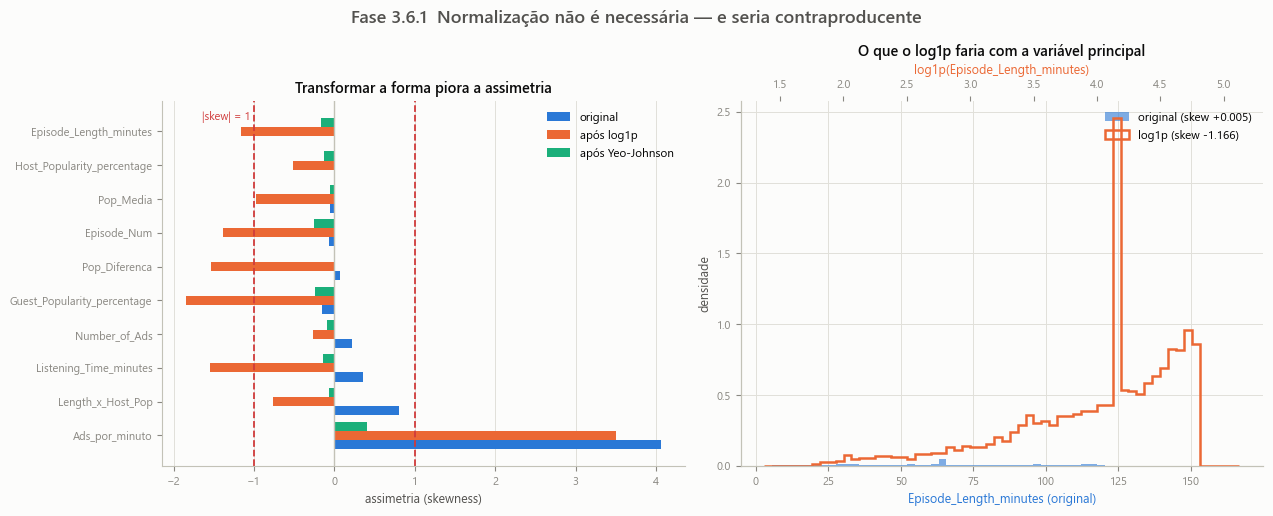

In [65]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.8, 5.2))

posicoes = np.arange(len(assimetria))
largura = 0.27
ax1.barh(posicoes - largura, assimetria["skew_original"], height=largura,
         color=SERIE_1, label="original")
ax1.barh(posicoes, assimetria["skew_apos_log1p"], height=largura,
         color=SERIE_2, label="após log1p")
ax1.barh(posicoes + largura, assimetria["skew_apos_yeo_johnson"], height=largura,
         color=SERIE_3, label="após Yeo-Johnson")
ax1.axvline(0, color=EIXO, linewidth=1.0)
for limite in (-cfg.limite_skew, cfg.limite_skew):
    ax1.axvline(limite, color=STATUS["critico"], linewidth=1.3, linestyle="--")
ax1.text(-cfg.limite_skew, len(assimetria) - 0.4, " |skew| = 1 ",
         color=STATUS["critico"], fontsize=8, ha="right", va="top")
ax1.set_yticks(posicoes, assimetria["coluna"], fontsize=8)
ax1.set_xlabel("assimetria (skewness)")
ax1.set_title("Transformar a forma piora a assimetria")
ax1.legend()
ax1.grid(axis="y", visible=False)

serie = p_train["Episode_Length_minutes"]
ax2.hist(serie, bins=60, density=True, color=SERIE_1, alpha=0.6,
         edgecolor="none", label=f"original (skew {serie.skew():+.3f})")
ax2_gemeo = ax2.twiny()
transformada = np.log1p(serie)
ax2_gemeo.hist(transformada, bins=60, density=True, histtype="step",
               color=SERIE_2, linewidth=1.8,
               label=f"log1p (skew {transformada.skew():+.3f})")
ax2.set_xlabel("Episode_Length_minutes (original)", color=SERIE_1)
ax2_gemeo.set_xlabel("log1p(Episode_Length_minutes)", color=SERIE_2)
ax2.set_ylabel("densidade")
ax2.set_title("O que o log1p faria com a variável principal")
ax2_gemeo.grid(visible=False)
linhas1, rotulos1 = ax2.get_legend_handles_labels()
linhas2, rotulos2 = ax2_gemeo.get_legend_handles_labels()
ax2.legend(linhas1 + linhas2, rotulos1 + rotulos2, loc="upper right")

fig.suptitle("Fase 3.6.1  Normalização não é necessária — e seria contraproducente",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Confirmado para tudo que veio do dataset original.** Depois da correção de domínio
da 3.1, nenhuma coluna original passa de |skew| = 0,35 — o limite do projeto para
assimetria relevante é 1,0. As distribuições são quase uniformes (kurtosis entre
−0,7 e −1,3), e uma uniforme já é **simétrica**: não há assimetria para corrigir.

O `log1p` não só é desnecessário como **inverte o problema**: `Episode_Length_minutes`
sai de skew +0,005 (praticamente perfeita) para **−1,17**, uma cauda longa à
esquerda que não existia. O painel da direita mostra por quê: o log comprime os
valores altos e espalha os baixos, entortando uma distribuição que estava plana.
A coluna `log1p_melhorou` da tabela é `False` em toda linha que já era simétrica.

O Yeo-Johnson se comporta melhor (chega a −0,17) mas também não melhora nada, e
custa a interpretabilidade — "minutos" viram uma escala sem unidade.

**Uma exceção, e ela é criada por nós:** `Ads_por_minuto` tem skew **+4,06**, bem
acima do limite. Não é um defeito do dado original — é o efeito de dividir por uma
duração que pode ser pequena. A célula seguinte decide o que fazer com ela.

**Decisão para todo o resto: nenhuma transformação de forma.** Nem no alvo (a Fase
2.2 já tinha chegado à mesma conclusão), nem nas preditoras originais.

### A exceção: `Ads_por_minuto`

Uma única coluna quebra o padrão, e ela é justamente a feature mais útil da 3.4.
Vale checar se o argumento "não precisa normalizar" sobrevive a ela.

In [66]:
razao = p_train["Ads_por_minuto"]
print(f"Ads_por_minuto: skew {razao.skew():+.3f}, kurtosis {razao.kurt():.1f}, "
      f"{100 * (razao == 0).mean():.1f}% de zeros")
print("A assimetria vem da construção: dividir uma contagem de 0 a 3 pela duração\n"
      "gera uma cauda longa nos episódios curtos com muitos anúncios.\n")

# A pergunta certa não é 'a distribuição ficou mais bonita?', e sim 'o modelo
# melhora?'. Testamos os dois lados.
sem_transformar = BASE_R2 + ["Ads_por_minuto"]
com_log = p_train[BASE_R2].assign(Ads_por_minuto_log=np.log1p(razao))

r2_sem = LinearRegression().fit(p_train[sem_transformar], y_aval).score(
    p_train[sem_transformar], y_aval)
r2_log = LinearRegression().fit(com_log, y_aval).score(com_log, y_aval)

display(pd.DataFrame([
    {"versao": "Ads_por_minuto", "skew": razao.skew(),
     "corr_com_alvo": razao.corr(p_train[cfg.target]), "r2_do_modelo": r2_sem},
    {"versao": "log1p(Ads_por_minuto)", "skew": float(np.log1p(razao).skew()),
     "corr_com_alvo": np.log1p(razao).corr(p_train[cfg.target]), "r2_do_modelo": r2_log},
]))

print("Decisão: manter sem transformar. O log1p mal mexe na assimetria (4,06 -> 3,51,\n"
      "porque 29% dos valores são zero e o log não separa zeros) e o R² muda na\n"
      "quinta casa decimal. E as árvores da Fase 4 são invariantes a transformações\n"
      "monotônicas: para elas as duas versões são literalmente a mesma coluna.")

Ads_por_minuto: skew +4.058, kurtosis 23.8, 29.0% de zeros
A assimetria vem da construção: dividir uma contagem de 0 a 3 pela duração
gera uma cauda longa nos episódios curtos com muitos anúncios.



,versao,skew,corr_com_alvo,r2_do_modelo
0,Ads_por_minuto,4.0577,-0.4517,0.7585
1,log1p(Ads_por_minuto),3.5051,-0.4647,0.7586


Decisão: manter sem transformar. O log1p mal mexe na assimetria (4,06 -> 3,51,
porque 29% dos valores são zero e o log não separa zeros) e o R² muda na
quinta casa decimal. E as árvores da Fase 4 são invariantes a transformações
monotônicas: para elas as duas versões são literalmente a mesma coluna.


### 3.6.2 Escalonar (mudar a ordem de grandeza) é necessário?

In [67]:
escalas = p_train[CONTINUAS].agg(["min", "max", "mean", "std"]).T
escalas["amplitude"] = escalas["max"] - escalas["min"]
escalas = escalas.sort_values("amplitude", ascending=False)
display(escalas)

maior, menor = escalas.iloc[0], escalas.iloc[-1]
razao_amplitudes = f"{maior['amplitude'] / menor['amplitude']:,.0f}".replace(",", ".")
maior_max = f"{maior['max']:,.0f}".replace(",", ".")

print(f"Amplitude da maior coluna / amplitude da menor: {razao_amplitudes}x")
print("\nNum modelo que soma coeficientes vezes valores (regressão linear, SVM) ou")
print(f"mede distância euclidiana (KNN), {escalas.index[0]} (0 a {maior_max})")
print(f"domina {escalas.index[-1]} (0 a {menor['max']:.2f}) - não por ser mais")
print("importante, mas por ser numericamente maior.")

,min,max,mean,std,amplitude
Length_x_Host_Pop,61.4460,"11,994.6006","3,872.5267","2,513.9589","11,933.1546"
Pop_Diferenca,-79.5100,99.9500,7.3614,33.9327,179.4600
Episode_Length_minutes,2.9700,166.6300,64.4306,30.9941,163.6600
Guest_Popularity_percentage,0.0000,100.0000,52.4979,25.5367,100.0000
Episode_Num,1.0000,100.0000,51.4451,28.0854,99.0000
Host_Popularity_percentage,1.3000,100.0000,59.8593,22.8722,98.7000
Pop_Media,3.7550,99.9600,56.1786,17.3140,96.2050
Number_of_Ads,0.0000,3.0000,1.3480,1.1110,3.0000
Ads_por_minuto,0.0000,0.6734,0.0333,0.0515,0.6734


Amplitude da maior coluna / amplitude da menor: 17.721x

Num modelo que soma coeficientes vezes valores (regressão linear, SVM) ou
mede distância euclidiana (KNN), Length_x_Host_Pop (0 a 11.995)
domina Ads_por_minuto (0 a 0.67) - não por ser mais
importante, mas por ser numericamente maior.


In [68]:
ESCALONAR = (NUMERICAS_ORIGINAIS
             + ["Ads_por_minuto", "Length_x_Host_Pop", "Pop_Media", "Pop_Diferenca",
                "Episode_Num", "Publication_Time_ord", "Sentimento_ord"]
             + nomes_te)

minmax = MinMaxScaler().fit(p_train[ESCALONAR])
standard = StandardScaler().fit(p_train[ESCALONAR])

mm_train = pd.DataFrame(minmax.transform(p_train[ESCALONAR]), columns=ESCALONAR)
mm_test = pd.DataFrame(minmax.transform(p_test[ESCALONAR]), columns=ESCALONAR)
ss_train = pd.DataFrame(standard.transform(p_train[ESCALONAR]), columns=ESCALONAR)

comparacao_escalas = pd.DataFrame({
    "skew_original": p_train[ESCALONAR].skew(),
    "skew_minmax": mm_train.skew(),
    "skew_standard": ss_train.skew(),
    "corr_original_vs_minmax": [p_train[c].corr(mm_train[c]) for c in ESCALONAR],
    "min_minmax": mm_train.min(),
    "max_minmax": mm_train.max(),
    "media_standard": ss_train.mean(),
    "desvio_standard": ss_train.std(),
})
display(comparacao_escalas.round(6))

print("A assimetria é IDÊNTICA nas três colunas e a correlação com a original é")
print("exatamente 1,000000. Isso não é coincidência: os dois escalonadores aplicam")
print("uma transformação AFIM (x -> a*x + b), e transformação afim não muda a forma")
print("da distribuição - só o eixo em que ela é lida.")

,skew_original,skew_minmax,skew_standard,corr_original_vs_minmax,min_minmax,max_minmax,media_standard,desvio_standard
Episode_Length_minutes,0.0046,0.0046,0.0046,1.0000,0.0000,1.0000,0.0000,1.0000
Host_Popularity_percentage,0.0048,0.0048,0.0048,1.0000,0.0000,1.0000,-0.0000,1.0000
Guest_Popularity_percentage,-0.1500,-0.1500,-0.1500,1.0000,0.0000,1.0000,0.0000,1.0000
Number_of_Ads,0.2180,0.2180,0.2180,1.0000,0.0000,1.0000,0.0000,1.0000
Ads_por_minuto,4.0577,4.0577,4.0577,1.0000,0.0000,1.0000,-0.0000,1.0000
Length_x_Host_Pop,0.7989,0.7989,0.7989,1.0000,0.0000,1.0000,-0.0000,1.0000
Pop_Media,-0.0576,-0.0576,-0.0576,1.0000,0.0000,1.0000,0.0000,1.0000
Pop_Diferenca,0.0695,0.0695,0.0695,1.0000,0.0000,1.0000,-0.0000,1.0000
Episode_Num,-0.0619,-0.0619,-0.0619,1.0000,0.0000,1.0000,-0.0000,1.0000
Publication_Time_ord,-0.0680,-0.0680,-0.0680,1.0000,0.0000,1.0000,0.0000,1.0000


A assimetria é IDÊNTICA nas três colunas e a correlação com a original é
exatamente 1,000000. Isso não é coincidência: os dois escalonadores aplicam
uma transformação AFIM (x -> a*x + b), e transformação afim não muda a forma
da distribuição - só o eixo em que ela é lida.


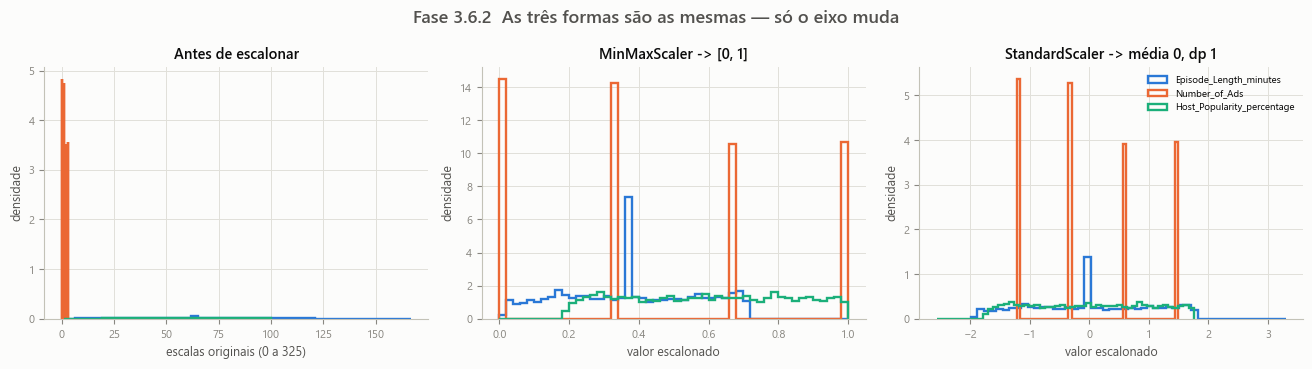

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.7))
colunas_mostradas = ["Episode_Length_minutes", "Number_of_Ads", "Host_Popularity_percentage"]

for ax, (titulo, dados) in zip(
    axes,
    [("Antes de escalonar", p_train[colunas_mostradas]),
     ("MinMaxScaler -> [0, 1]", mm_train[colunas_mostradas]),
     ("StandardScaler -> média 0, dp 1", ss_train[colunas_mostradas])],
):
    for coluna, cor in zip(colunas_mostradas, (SERIE_1, SERIE_2, SERIE_3)):
        ax.hist(dados[coluna], bins=50, density=True, histtype="step",
                linewidth=1.7, color=cor, label=coluna)
    ax.set_title(titulo)
    ax.set_ylabel("densidade")
axes[0].set_xlabel("escalas originais (0 a 325)")
axes[1].set_xlabel("valor escalonado")
axes[2].set_xlabel("valor escalonado")
axes[2].legend(fontsize=7)

fig.suptitle("Fase 3.6.2  As três formas são as mesmas — só o eixo muda",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

**Um ajuste ao raciocínio da equipe.** A conclusão — usar `MinMaxScaler` — está
certa, mas o motivo apresentado ("ele preserva a distribuição uniforme e não força
artificialmente uma curva normal") merece uma correção: **o `StandardScaler` também
preserva**. Nenhum dos dois pode forçar normalidade, porque ambos são
transformações afins. O `StandardScaler` divide pelo desvio padrão; ele não
"normaliza" no sentido de mudar a forma, apesar do nome sugerir isso. Quem muda a
forma é o `PowerTransformer` da seção anterior — e já vimos que aqui ele atrapalha.

Os painéis mostram exatamente isso: as três curvas têm o mesmo desenho nos três
gráficos, só o eixo horizontal muda.

**Dito isso, `MinMaxScaler` continua sendo a escolha certa aqui**, por dois motivos
que os dados sustentam:

1. **As variáveis têm limites naturais rígidos.** Percentuais vivem em [0, 100],
   `Number_of_Ads` em [0, 3], e a 3.1 impôs esses limites explicitamente. Mapear
   para [0, 1] preserva esse significado: 0,5 é literalmente "metade do máximo
   possível". Já a média e o desvio padrão do `StandardScaler` são resumos que
   descrevem bem uma normal e mal uma uniforme — em uma uniforme, "1 desvio padrão
   acima da média" não é um evento raro, é rotina.
2. **Compatibilidade com a Fase 5.** O alvo está restrito a [0, 120] e o plano
   prevê recortar as previsões nesse intervalo; trabalhar em [0, 1] mantém o
   raciocínio de limites coerente de ponta a ponta.

### O detalhe que faz o escalonamento depender da Fase 3.3

`MinMaxScaler` é o mais sensível a extremos de todos os escalonadores: um único
valor absurdo no `fit` esmaga todo o resto contra o zero. É por isso que ele vem
**depois** da correção de domínio e do recorte de outliers, e não antes.

O `test.csv` oferece a demonstração perfeita — ele contém um episódio de
**78.486.264 minutos** (Fase 1.4).

In [70]:
bruto_minmax = MinMaxScaler().fit(train[NUMERICAS_ORIGINAIS].fillna(train[NUMERICAS_ORIGINAIS].median()))
test_sem_tratamento = pd.DataFrame(
    bruto_minmax.transform(test[NUMERICAS_ORIGINAIS].fillna(train[NUMERICAS_ORIGINAIS].median())),
    columns=NUMERICAS_ORIGINAIS,
)

comparacao_extremos = pd.DataFrame([
    {
        "coluna": c,
        "min_test_sem_3.1_e_3.3": test_sem_tratamento[c].min(),
        "max_test_sem_3.1_e_3.3": test_sem_tratamento[c].max(),
        "min_test_com_tratamento": mm_test[c].min(),
        "max_test_com_tratamento": mm_test[c].max(),
        "linhas_fora_de_0_1_sem_tratamento": int(((test_sem_tratamento[c] < 0) | (test_sem_tratamento[c] > 1)).sum()),
        "linhas_fora_de_0_1_com_tratamento": int(((mm_test[c] < 0) | (mm_test[c] > 1)).sum()),
    }
    for c in NUMERICAS_ORIGINAIS
])
display(comparacao_extremos)

pior = comparacao_extremos.loc[comparacao_extremos["max_test_sem_3.1_e_3.3"].idxmax()]
pior_valor = f"{pior['max_test_sem_3.1_e_3.3']:,.0f}".replace(",", ".")
print(f"Sem as etapas 3.1 e 3.3, o episódio de 78 milhões de minutos vira "
      f"{pior_valor} na escala [0,1]")
print("- e comprime todos os episódios reais num intervalo colado no zero. O mesmo")
print(f"acontece com Number_of_Ads, que chega a "
      f"{comparacao_extremos.loc[3, 'max_test_sem_3.1_e_3.3']:.1f} por causa do valor 2.063.\n")
print("Com o tratamento, o test praticamente cabe em [0,1]:")
print(f"  antes:  {int(comparacao_extremos['linhas_fora_de_0_1_sem_tratamento'].sum())} linhas fora")
print(f"  depois: {int(comparacao_extremos['linhas_fora_de_0_1_com_tratamento'].sum())} linha(s) fora\n")
print("Sobrar 1 linha fora não é falha: os limites vêm do train, e o test tem uma")
print("duração ligeiramente abaixo do mínimo do train. Forçá-la para dentro exigiria")
print("reajustar o escalonador no test - isso sim seria vazamento.")

,coluna,min_test_sem_3.1_e_3.3,max_test_sem_3.1_e_3.3,min_test_com_tratamento,max_test_com_tratamento,linhas_fora_de_0_1_sem_tratamento,linhas_fora_de_0_1_com_tratamento
0,Episode_Length_minutes,0.0076,"241,317.9929",-0.0031,1.0000,2,1
1,Host_Popularity_percentage,0.0101,0.9856,0.0121,1.0000,0,0
2,Guest_Popularity_percentage,0.0000,0.9742,0.0000,1.0000,0,0
3,Number_of_Ads,0.0000,19.8537,0.0000,1.0000,1,0


Sem as etapas 3.1 e 3.3, o episódio de 78 milhões de minutos vira 241.318 na escala [0,1]
- e comprime todos os episódios reais num intervalo colado no zero. O mesmo
acontece com Number_of_Ads, que chega a 19.9 por causa do valor 2.063.

Com o tratamento, o test praticamente cabe em [0,1]:
  antes:  3 linhas fora
  depois: 1 linha(s) fora

Sobrar 1 linha fora não é falha: os limites vêm do train, e o test tem uma
duração ligeiramente abaixo do mínimo do train. Forçá-la para dentro exigiria
reajustar o escalonador no test - isso sim seria vazamento.


## 3.7 Seleção de features

Bloco `VIF · feature importance · correlação > 0.9` do diagrama. A Fase 2.5 concluiu
que "a etapa de seleção por VIF não vai eliminar nada" — e estava certa **sobre as
variáveis originais**. A engenharia de features da 3.4 mudou o quadro: features
derivadas de outras features são, por construção, candidatas a multicolinearidade.

### 3.7.1 Correlação entre preditoras

In [71]:
CANDIDATAS = (NUMERICAS_ORIGINAIS + NOVAS_FEATURES + nomes_te + nomes_ohe)
X_candidatas = p_train[CANDIDATAS]

matriz_corr = X_candidatas.corr()
pares_redundantes = pd.DataFrame([
    {"variavel_a": a, "variavel_b": b, "pearson": round(float(matriz_corr.loc[a, b]), 4)}
    for i, a in enumerate(CANDIDATAS) for b in CANDIDATAS[i + 1:]
    if abs(matriz_corr.loc[a, b]) >= cfg.limite_correlacao_alta
])
print(f"Pares com |r| >= {cfg.limite_correlacao_alta}: {len(pares_redundantes)}")

maiores = sorted(
    ({"variavel_a": a, "variavel_b": b, "pearson": round(float(matriz_corr.loc[a, b]), 4)}
     for i, a in enumerate(CANDIDATAS) for b in CANDIDATAS[i + 1:]),
    key=lambda d: -abs(d["pearson"]),
)[:10]
print("\nOs 10 pares mais correlacionados:")
display(pd.DataFrame(maiores))

Pares com |r| >= 0.9: 0

Os 10 pares mais correlacionados:


,variavel_a,variavel_b,pearson
0,Episode_Length_minutes,Length_x_Host_Pop,0.7537
1,Guest_Popularity_percentage,Pop_Media,0.7509
2,Guest_Popularity_percentage,Pop_Diferenca,-0.7388
3,Host_Popularity_percentage,Pop_Media,0.6756
4,Is_Weekend,Publication_Day_Sunday,0.6649
5,Host_Popularity_percentage,Pop_Diferenca,0.6587
6,Is_Weekend,Publication_Day_Saturday,0.6221
7,Host_Popularity_percentage,Length_x_Host_Pop,0.6098
8,Number_of_Ads,Ads_por_minuto,0.5355
9,Episode_Length_minutes,Ads_por_minuto,-0.4994


### 3.7.2 VIF — o que a correlação par a par não vê

O VIF (Variance Inflation Factor) mede o quanto **todas as outras** features juntas
explicam uma dada feature: `VIF = 1 / (1 - R²)`. A regra usual é VIF > 10 =
multicolinearidade séria. Ele acha o que a correlação par a par não acha, porque uma
feature pode ser combinação de **várias** outras sem se parecer muito com nenhuma
delas em particular.

In [72]:
def calcular_vif(X):
    """VIF de cada coluna: 1 / (1 - R² da regressão dela contra as demais).

    R² indistinguível de 1 significa redundância exata (a coluna é combinação
    linear das outras); o VIF é infinito e o relatamos como tal.
    """
    linhas = []
    for coluna in X.columns:
        outras = X.drop(columns=coluna)
        r2 = LinearRegression().fit(outras, X[coluna]).score(outras, X[coluna])
        vif = np.inf if r2 >= 1 - 1e-10 else 1.0 / (1.0 - r2)
        linhas.append({"feature": coluna, "r2_contra_as_outras": r2, "vif": vif})
    return pd.DataFrame(linhas).sort_values("vif", ascending=False).reset_index(drop=True)


vif_completo = calcular_vif(X_candidatas)
display(vif_completo.head(12))

LIMITE_VIF = 10.0
suspeitas = vif_completo[vif_completo["vif"] > LIMITE_VIF]["feature"].tolist()
print(f"Features com VIF > {LIMITE_VIF:.0f}: {suspeitas}")

,feature,r2_contra_as_outras,vif
0,Host_Popularity_percentage,1.0000,inf
1,Guest_Popularity_percentage,1.0000,inf
2,Is_Weekend,1.0000,inf
3,Pop_Diferenca,1.0000,inf
4,Pop_Media,1.0000,inf
5,Publication_Day_Saturday,1.0000,inf
6,Publication_Day_Sunday,1.0000,inf
7,Length_x_Host_Pop,0.9199,12.4906
8,Episode_Length_minutes,0.8797,8.3149
9,Ads_por_minuto,0.5166,2.0686


Features com VIF > 10: ['Host_Popularity_percentage', 'Guest_Popularity_percentage', 'Is_Weekend', 'Pop_Diferenca', 'Pop_Media', 'Publication_Day_Saturday', 'Publication_Day_Sunday', 'Length_x_Host_Pop']


**Sete features com VIF infinito e uma com 12,5 — num dataset onde a regra
`|r| > 0,9` não encontrou absolutamente nada.**

VIF infinito significa **redundância exata**: a feature é combinação linear das
outras, sem sobra. E ele acusa o *grupo* inteiro, não o culpado — quando quatro
colunas satisfazem uma identidade, as quatro aparecem com VIF infinito. Há dois
grupos aqui, ambos criados pela engenharia de features da 3.4:

**Grupo 1 — as popularidades.** `Pop_Media = (Host + Guest) / 2` e
`Pop_Diferenca = Host − Guest`. Duas quaisquer dessas quatro colunas determinam as
outras duas por álgebra elementar. As quatro aparecem com VIF infinito.

**Grupo 2 — o fim de semana.** `Is_Weekend` é *exatamente*
`Publication_Day_Saturday + Publication_Day_Sunday`. As três aparecem com VIF
infinito, e a correlação par a par mais alta entre elas é 0,66 — **a regra
`|r| > 0,9` do diagrama jamais encontraria essa identidade**. É o argumento de
existência do VIF.

**E `Length_x_Host_Pop`**, a interação sugerida pelo diagrama, com VIF 12,5. Não é
redundância exata (é um *produto*, não uma soma), mas é o bastante para inflar
junto o VIF de `Episode_Length_minutes` para 8,3 e o de
`Host_Popularity_percentage`. Já sabíamos da 3.4 que ela acrescenta +0,0004 de R²;
agora sabemos que também cobra caro por isso.

**A poda:** basta quebrar cada dependência, não eliminar o grupo. Saem
`Pop_Media` e `Pop_Diferenca` (as derivadas, preservando as originais
interpretáveis), `Is_Weekend` (preservando as dummies, que são mais granulares) e
`Length_x_Host_Pop`.

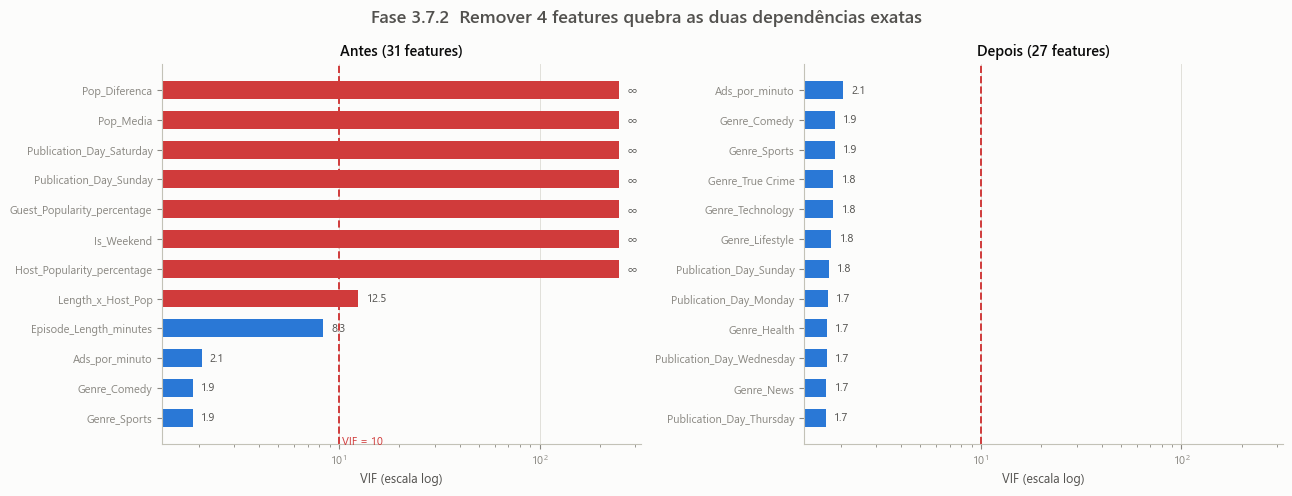

VIF infinito antes:  7 features
VIF infinito depois: 0 features
VIF máximo finito depois: 2.07


In [73]:
REDUNDANTES_POR_CONSTRUCAO = ["Pop_Media", "Pop_Diferenca", "Is_Weekend", "Length_x_Host_Pop"]
CANDIDATAS_PODADAS = [c for c in CANDIDATAS if c not in REDUNDANTES_POR_CONSTRUCAO]
vif_podado = calcular_vif(p_train[CANDIDATAS_PODADAS])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.0), sharex=True)
for ax, (tabela, titulo) in zip(
    (ax1, ax2),
    [(vif_completo, f"Antes ({len(CANDIDATAS)} features)"),
     (vif_podado, f"Depois ({len(CANDIDATAS_PODADAS)} features)")],
):
    exibida = tabela.head(12).sort_values("vif")
    pos = np.arange(len(exibida))
    # O VIF infinito não tem posição num eixo: desenhado no topo da escala.
    teto = exibida["vif"].replace(np.inf, np.nan).max() * 20
    valores = exibida["vif"].replace(np.inf, teto)
    cores = [STATUS["critico"] if v > LIMITE_VIF else SERIE_1 for v in valores]
    ax.barh(pos, valores, color=cores, height=0.6)
    ax.set_yticks(pos, exibida["feature"], fontsize=8)
    ax.axvline(LIMITE_VIF, color=STATUS["critico"], linewidth=1.4, linestyle="--")
    ax.set_xscale("log")
    ax.set_xlabel("VIF (escala log)")
    ax.set_title(titulo)
    ax.grid(axis="y", visible=False)
    for y, (v, bruto) in zip(pos, zip(valores, exibida["vif"])):
        rotulo = "∞" if np.isinf(bruto) else f"{bruto:.1f}"
        ax.text(v * 1.1, y, rotulo, va="center", fontsize=8, color=TINTA_SECUNDARIA)
ax1.text(LIMITE_VIF, -0.9, " VIF = 10", color=STATUS["critico"], fontsize=8)

fig.suptitle(f"Fase 3.7.2  Remover {len(REDUNDANTES_POR_CONSTRUCAO)} features quebra "
             "as duas dependências exatas",
             fontsize=13, fontweight="semibold", color=TINTA_SECUNDARIA)
fig.tight_layout()
plt.show()

print(f"VIF infinito antes:  {int(np.isinf(vif_completo['vif']).sum())} features")
print(f"VIF infinito depois: {int(np.isinf(vif_podado['vif']).sum())} features")
print(f"VIF máximo finito depois: {vif_podado['vif'].replace(np.inf, np.nan).max():.2f}")

### 3.7.3 Importância por permutação

O VIF cuida da redundância; falta saber o que é **útil**. A importância por
permutação embaralha uma coluna de cada vez e mede o quanto o erro do modelo piora:
se embaralhar não muda nada, a coluna não estava sendo usada. Diferente da
importância interna das árvores, ela funciona para qualquer modelo e não favorece
variáveis de alta cardinalidade.

In [74]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

amostra_imp = p_train.sample(n=60_000, random_state=cfg.random_state)
X_imp = amostra_imp[CANDIDATAS_PODADAS]
y_imp = amostra_imp[cfg.target]
X_ajuste, X_valida, y_ajuste, y_valida = train_test_split(
    X_imp, y_imp, test_size=0.3, random_state=cfg.random_state)

modelo_imp = HistGradientBoostingRegressor(max_iter=200, random_state=cfg.random_state)
modelo_imp.fit(X_ajuste, y_ajuste)
print(f"R² do modelo de referência (HistGB, validação): {modelo_imp.score(X_valida, y_valida):.4f}")

perm = permutation_importance(modelo_imp, X_valida, y_valida, n_repeats=5,
                              random_state=cfg.random_state, scoring="neg_root_mean_squared_error")
importancia = (pd.DataFrame({
    "feature": CANDIDATAS_PODADAS,
    "aumento_de_rmse": perm.importances_mean,
    "desvio": perm.importances_std,
}).sort_values("aumento_de_rmse", ascending=False).reset_index(drop=True))
display(importancia.head(15))

R² do modelo de referência (HistGB, validação): 0.7590


,feature,aumento_de_rmse,desvio
0,Episode_Length_minutes,21.0637,0.1554
1,Ads_por_minuto,0.5266,0.0298
2,Host_Popularity_percentage,0.1728,0.0082
3,Guest_Popularity_percentage,0.0300,0.0044
4,Episode_Title_te,0.0283,0.0082
5,Sentimento_ord,0.0199,0.0052
6,Length_Ausente,0.0158,0.0044
7,Podcast_Name_te,0.0133,0.0049
8,Genre_Technology,0.0057,0.0024
9,Sem_Convidado,0.0025,0.0003


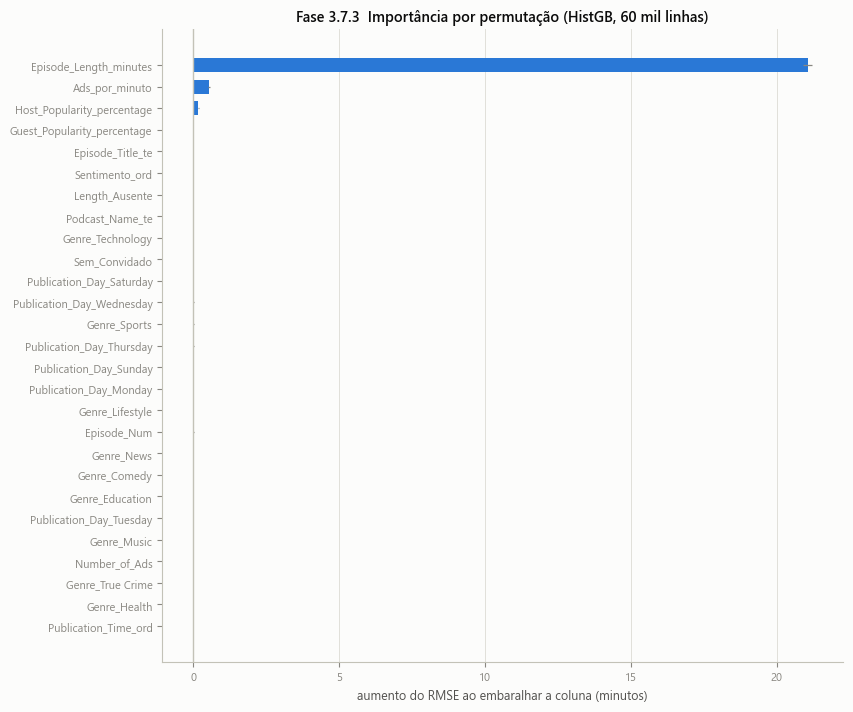

19 features com efeito praticamente nulo (<= 0,01 min de RMSE):
Genre_Technology, Sem_Convidado, Publication_Day_Saturday, Publication_Day_Wednesday, Genre_Sports, Publication_Day_Thursday, Publication_Day_Sunday, Publication_Day_Monday, Genre_Lifestyle, Episode_Num, Genre_News, Genre_Comedy, Genre_Education, Publication_Day_Tuesday, Genre_Music, Number_of_Ads, Genre_True Crime, Genre_Health, Publication_Time_ord


In [75]:
fig, ax = plt.subplots(figsize=(8.6, 7.2))
exibida = importancia.sort_values("aumento_de_rmse")
pos = np.arange(len(exibida))
cores = [SERIE_1 if v > 0.01 else TINTA_SUAVE for v in exibida["aumento_de_rmse"]]
ax.barh(pos, exibida["aumento_de_rmse"], xerr=exibida["desvio"], color=cores, height=0.66,
        error_kw={"ecolor": TINTA_SUAVE, "elinewidth": 0.9})
ax.set_yticks(pos, exibida["feature"], fontsize=8)
ax.axvline(0, color=EIXO, linewidth=1.0)
ax.set_xlabel("aumento do RMSE ao embaralhar a coluna (minutos)")
ax.set_title("Fase 3.7.3  Importância por permutação (HistGB, 60 mil linhas)")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

irrelevantes = importancia[importancia["aumento_de_rmse"] <= 0.01]["feature"].tolist()
print(f"{len(irrelevantes)} features com efeito praticamente nulo (<= 0,01 min de RMSE):")
print(", ".join(irrelevantes))

**A escala do gráfico conta a história sozinha.** Embaralhar
`Episode_Length_minutes` piora o RMSE em **21,06 minutos**, num alvo cujo RMSE é
~13. A segunda colocada, `Ads_por_minuto`, custa 0,53 minuto — **40 vezes menos**.
É a Fase 2 confirmada num terceiro tipo de medida: o problema é quase
unidimensional.

Três leituras menos óbvias:

- **`Number_of_Ads` aparece com importância negativa** (−0,0013): embaralhá-la
  chega a melhorar o modelo, dentro do ruído. Não é que anúncios não importem — a
  3.4 mostrou que importam — é que `Ads_por_minuto` já carrega a informação numa
  forma melhor. A permutação mede o que é *insubstituível*, não o que é útil; quando
  duas colunas dizem a mesma coisa, embaralhar uma não dói.
- **O target encoding ganha do número extraído, e não é páreo.** `Episode_Title_te`
  rende 0,028 e `Episode_Num` rende 0,0001 — com desvio de 0,008, ou seja,
  indistinguível de zero. As duas vêm da mesma coluna original: o efeito do título
  não é monotônico no número do episódio, exatamente como a 3.5 antecipou. Fosse só
  por isso, `Episode_Num` poderia sair; fica porque não custa nada e as árvores
  podem usá-la de forma que o modelo linear não usaria.
- **19 das 27 features têm efeito ≤ 0,01 minuto** — abaixo de um décimo de por
  cento do RMSE. As dummies de `Genre` e `Publication_Day` estão quase todas aí,
  coerente com os η² de 0,0006 da Fase 2.4.

### 3.7.4 A decisão

O diagrama trata a seleção de features como um passo obrigatório. Aqui ela precisa
de um critério, porque há duas famílias de modelos com necessidades opostas:

- **Modelos lineares** sofrem com multicolinearidade — coeficientes ficam instáveis
  e sem interpretação. Para eles, remover as features de VIF alto é obrigatório.
- **Modelos de árvore** são indiferentes a multicolinearidade e a features inúteis:
  eles simplesmente não escolhem essas colunas para dividir. Podar para eles rende
  pouco além de velocidade.

Como a Fase 4 vai comparar as duas famílias, a matriz final mantém as features com
sinal e remove apenas as que são **redundantes por construção**.

In [76]:
REMOVIDAS = {
    "Length_x_Host_Pop": "VIF 12,5 e infla Episode_Length para 8,3; produto de duas colunas presentes",
    "Is_Weekend": "= Publication_Day_Saturday + Publication_Day_Sunday (VIF infinito)",
    "Pop_Media": "= (Host + Guest) / 2 (VIF infinito)",
    "Pop_Diferenca": "= Host - Guest (VIF infinito)",
}

FEATURES_FINAIS = [c for c in CANDIDATAS if c not in REMOVIDAS]

display(pd.DataFrame([
    {"feature_removida": c, "motivo": m,
     "ganho_de_r2_na_3.4": float(
         avaliacao_features.loc[avaliacao_features["feature"] == c, "ganho_de_r2"].iloc[0])
         if c in avaliacao_features["feature"].values else np.nan}
    for c, m in REMOVIDAS.items()
]))

for coluna, motivo in REMOVIDAS.items():
    registrar("3.7 seleção", f"{coluna} removida", 1, 1, motivo)

print(f"Features candidatas: {len(CANDIDATAS)}")
print(f"Features finais:     {len(FEATURES_FINAIS)}")
print(f"\nSe as categóricas tivessem ido para One-Hot: "
      f"{len(FEATURES_FINAIS) - len(nomes_te) + (48 - 1) + (100 - 1)} colunas "
      f"(+{(48 - 1) + (100 - 1) - len(nomes_te)} vindas de Podcast_Name e Episode_Title).")

,feature_removida,motivo,ganho_de_r2_na_3.4
0,Length_x_Host_Pop,"VIF 12,5 e infla Episode_Length para 8,3; prod...",0.0004
1,Is_Weekend,= Publication_Day_Saturday + Publication_Day_S...,0.0000
2,Pop_Media,= (Host + Guest) / 2 (VIF infinito),-0.0000
3,Pop_Diferenca,= Host - Guest (VIF infinito),-0.0000


Features candidatas: 31
Features finais:     27

Se as categóricas tivessem ido para One-Hot: 171 colunas (+144 vindas de Podcast_Name e Episode_Title).


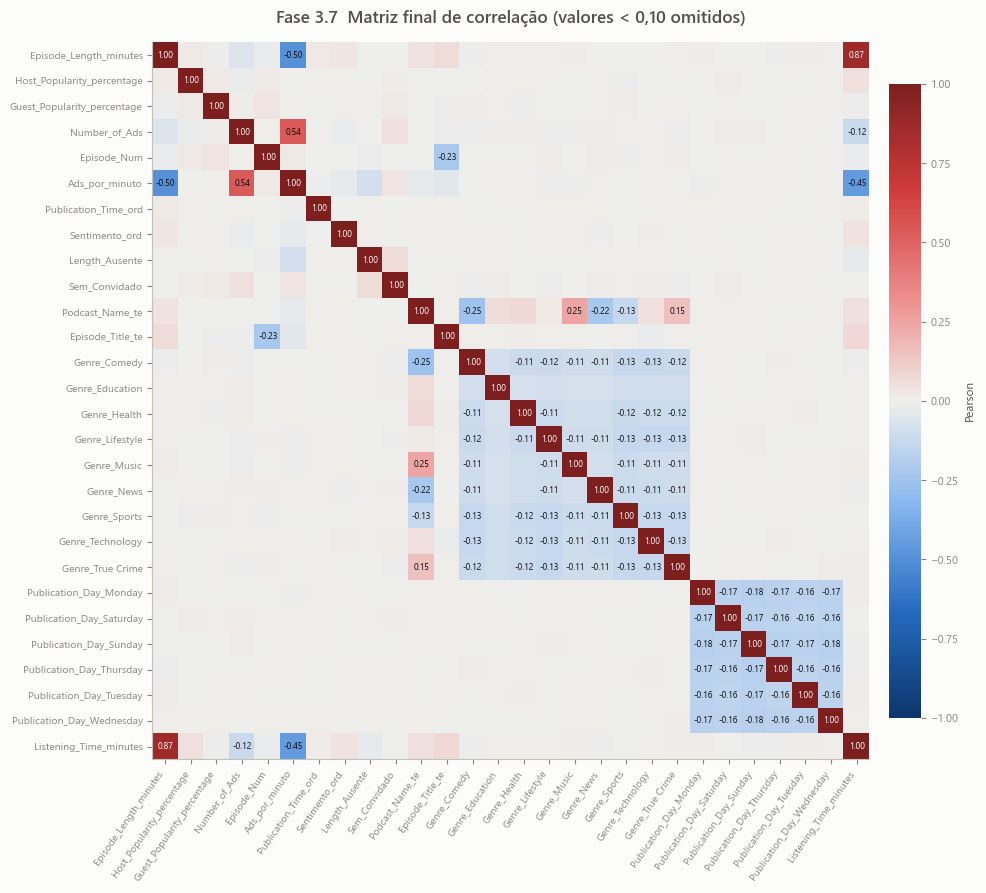

In [77]:
matriz_final_corr = p_train[FEATURES_FINAIS + [cfg.target]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
imagem = ax.imshow(matriz_final_corr.to_numpy(), cmap=DIVERGENTE, vmin=-1, vmax=1)
rotulos = list(matriz_final_corr.columns)
ax.set_xticks(range(len(rotulos)), rotulos, rotation=55, ha="right", fontsize=7.5)
ax.set_yticks(range(len(rotulos)), rotulos, fontsize=7.5)
ax.grid(visible=False)
for i in range(len(rotulos)):
    for j in range(len(rotulos)):
        v = matriz_final_corr.iat[i, j]
        if abs(v) >= 0.10:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.2,
                    color="#ffffff" if abs(v) > 0.55 else TINTA_PRIMARIA)
barra = fig.colorbar(imagem, ax=ax, fraction=0.032, pad=0.02)
barra.set_label("Pearson", color=TINTA_SECUNDARIA, fontsize=8.5)
barra.outline.set_visible(False)
ax.set_title("Fase 3.7  Matriz final de correlação (valores < 0,10 omitidos)",
             fontsize=12.5, fontweight="semibold", color=TINTA_SECUNDARIA, pad=14)
fig.tight_layout()
plt.show()

## 3.8 Matrizes finais e verificação

Quatro artefatos saem da Fase 3, e a escolha entre eles é do modelo, não do
pré-processamento:

| artefato | para quem |
|---|---|
| `X_train`, `X_test` | modelos de árvore (escala é irrelevante) |
| `X_train_mm`, `X_test_mm` | regressão linear, SVM, KNN (escala é essencial) |

In [78]:
X_train = p_train[FEATURES_FINAIS].copy()
y_train = p_train[cfg.target].copy()
X_test = p_test[FEATURES_FINAIS].copy()
ids_test = p_test[cfg.id_col].copy()

# O escalonador é reajustado sobre o conjunto final de features - e só no train.
ESCALONAR_FINAL = [c for c in FEATURES_FINAIS if not c.startswith(tuple(f"{o}_" for o in COLUNAS_OHE))]
escalonador_final = MinMaxScaler().fit(X_train[ESCALONAR_FINAL])

X_train_mm = X_train.copy()
X_test_mm = X_test.copy()
X_train_mm[ESCALONAR_FINAL] = escalonador_final.transform(X_train[ESCALONAR_FINAL])
X_test_mm[ESCALONAR_FINAL] = escalonador_final.transform(X_test[ESCALONAR_FINAL])

verificacoes = pd.DataFrame([
    {"verificacao": "X_train sem NaN", "obrigatoria": True,
     "resultado": int(X_train.isna().sum().sum()) == 0,
     "detalhe": f"{int(X_train.isna().sum().sum())} NaN"},
    {"verificacao": "X_test sem NaN", "obrigatoria": True,
     "resultado": int(X_test.isna().sum().sum()) == 0,
     "detalhe": f"{int(X_test.isna().sum().sum())} NaN"},
    {"verificacao": "mesmas colunas em train e test", "obrigatoria": True,
     "resultado": list(X_train.columns) == list(X_test.columns),
     "detalhe": f"{X_train.shape[1]} colunas"},
    {"verificacao": "todas as colunas numéricas", "obrigatoria": True,
     "resultado": X_train.select_dtypes(exclude="number").empty,
     "detalhe": ", ".join(X_train.select_dtypes(exclude="number").columns) or "nenhuma coluna de texto"},
    {"verificacao": "y sem NaN", "obrigatoria": True,
     "resultado": int(y_train.isna().sum()) == 0,
     "detalhe": f"{int(y_train.isna().sum())} NaN"},
    {"verificacao": "y dentro de [0, 120]", "obrigatoria": True,
     "resultado": bool(y_train.between(0, 120).all()),
     "detalhe": f"[{y_train.min():.2f}, {y_train.max():.2f}]"},
    # Só verificável onde a duração é o valor OBSERVADO: nas linhas imputadas, a
    # mediana substituiu a duração real e a comparação perde o sentido (ver 3.1).
    {"verificacao": "alvo <= duração (linhas com duração observada)", "obrigatoria": True,
     "resultado": bool((y_train[X_train["Length_Ausente"] == 0]
                        <= X_train.loc[X_train["Length_Ausente"] == 0, "Episode_Length_minutes"] + 1e-6).all()),
     "detalhe": f"{int((y_train[X_train['Length_Ausente'] == 0] > X_train.loc[X_train['Length_Ausente'] == 0, 'Episode_Length_minutes'] + 1e-6).sum())} violações"},
    # Informativa: nas linhas imputadas a violação é esperada e não indica erro.
    {"verificacao": "alvo <= duração (linhas com duração imputada)", "obrigatoria": False,
     "resultado": bool((y_train[X_train["Length_Ausente"] == 1]
                        <= X_train.loc[X_train["Length_Ausente"] == 1, "Episode_Length_minutes"] + 1e-6).all()),
     "detalhe": f"{int((y_train[X_train['Length_Ausente'] == 1] > X_train.loc[X_train['Length_Ausente'] == 1, 'Episode_Length_minutes'] + 1e-6).sum())} "
                "linhas onde o alvo passa da mediana imputada (esperado)"},
    {"verificacao": "X_train_mm dentro de [0, 1]", "obrigatoria": True,
     "resultado": bool(X_train_mm[ESCALONAR_FINAL].min().min() >= -1e-9
                       and X_train_mm[ESCALONAR_FINAL].max().max() <= 1 + 1e-9),
     "detalhe": f"[{X_train_mm[ESCALONAR_FINAL].min().min():.4f}, {X_train_mm[ESCALONAR_FINAL].max().max():.4f}]"},
    {"verificacao": "test manteve todas as linhas", "obrigatoria": True,
     "resultado": len(X_test) == len(test),
     "detalhe": f"{len(X_test):,} de {len(test):,}".replace(",", ".")},
    # Informativa, não obrigatória: os limites vêm do train, então o test PODE
    # sair de [0, 1]. Forçá-lo a caber seria reajustar no test, ou seja, vazamento.
    {"verificacao": "X_test_mm dentro de [0, 1]", "obrigatoria": False,
     "resultado": bool(X_test_mm[ESCALONAR_FINAL].min().min() >= -1e-9
                       and X_test_mm[ESCALONAR_FINAL].max().max() <= 1 + 1e-9),
     "detalhe": f"[{X_test_mm[ESCALONAR_FINAL].min().min():.4f}, {X_test_mm[ESCALONAR_FINAL].max().max():.4f}]"},
])
display(verificacoes)

print(f"X_train: {X_train.shape[0]:,} x {X_train.shape[1]}".replace(",", "."))
print(f"X_test:  {X_test.shape[0]:,} x {X_test.shape[1]}".replace(",", "."))
print(f"linhas removidas do train nesta fase: {len(train) - len(X_train):,}".replace(",", ".")
      + f"  ({100 * (len(train) - len(X_train)) / len(train):.4f}%)")

obrigatorias = verificacoes[verificacoes["obrigatoria"]]
print(f"\nverificações obrigatórias aprovadas: "
      f"{int(obrigatorias['resultado'].sum())}/{len(obrigatorias)}")

,verificacao,obrigatoria,resultado,detalhe
0,X_train sem NaN,True,True,0 NaN
1,X_test sem NaN,True,True,0 NaN
2,mesmas colunas em train e test,True,True,27 colunas
3,todas as colunas numéricas,True,True,nenhuma coluna de texto
4,y sem NaN,True,True,0 NaN
5,"y dentro de [0, 120]",True,True,"[0.00, 119.97]"
6,alvo <= duração (linhas com duração observada),True,True,0 violações
7,alvo <= duração (linhas com duração imputada),False,False,19673 linhas onde o alvo passa da mediana impu...
8,"X_train_mm dentro de [0, 1]",True,True,"[0.0000, 1.0000]"
9,test manteve todas as linhas,True,True,250.000 de 250.000


X_train: 749.916 x 27
X_test:  250.000 x 27
linhas removidas do train nesta fase: 84  (0.0112%)

verificações obrigatórias aprovadas: 9/9


### O ganho real da Fase 3, medido

Vale fechar a fase comparando o que sai dela com o que entrou, no mesmo modelo e com
validação honesta.

In [79]:
from sklearn.model_selection import KFold, cross_validate

# Ponto de partida: o dataset cru, com o mínimo indispensável para um modelo rodar.
cru = train[NUMERICAS_ORIGINAIS].fillna(train[NUMERICAS_ORIGINAIS].median())
y_cru = train[cfg.target]

# Amostra de 150 mil linhas para a validação cruzada caber em tempo razoável.
# Cada conjunto tem seu próprio sorteio porque têm números de linhas diferentes.
sorteio = np.random.default_rng(cfg.random_state)
amostra_cv = sorteio.choice(len(X_train), 150_000, replace=False)
amostra_cru = sorteio.choice(len(cru), 150_000, replace=False)
dobras = KFold(n_splits=5, shuffle=True, random_state=cfg.random_state)


def avaliar(nome, X, y, modelo):
    pontuacao = cross_validate(modelo, X, y, cv=dobras,
                               scoring=["neg_root_mean_squared_error", "r2"], n_jobs=1)
    return {
        "cenario": nome,
        "n_features": X.shape[1],
        "rmse": -pontuacao["test_neg_root_mean_squared_error"].mean(),
        "rmse_desvio": pontuacao["test_neg_root_mean_squared_error"].std(),
        "r2": pontuacao["test_r2"].mean(),
    }


comparacao_final = pd.DataFrame([
    avaliar("cru + mediana (linear)", cru.iloc[amostra_cru], y_cru.iloc[amostra_cru], LinearRegression()),
    avaliar("Fase 3 escalonada (linear)", X_train_mm.iloc[amostra_cv], y_train.iloc[amostra_cv], LinearRegression()),
    avaliar("cru + mediana (HistGB)", cru.iloc[amostra_cru], y_cru.iloc[amostra_cru],
            HistGradientBoostingRegressor(max_iter=200, random_state=cfg.random_state)),
    avaliar("Fase 3 (HistGB)", X_train.iloc[amostra_cv], y_train.iloc[amostra_cv],
            HistGradientBoostingRegressor(max_iter=200, random_state=cfg.random_state)),
])
comparacao_final["ganho_rmse_vs_cru"] = [
    np.nan,
    comparacao_final.loc[0, "rmse"] - comparacao_final.loc[1, "rmse"],
    np.nan,
    comparacao_final.loc[2, "rmse"] - comparacao_final.loc[3, "rmse"],
]
comparacao_final

,cenario,n_features,rmse,rmse_desvio,r2,ganho_rmse_vs_cru
0,cru + mediana (linear),4,13.3667,0.0505,0.7571,NaN
1,Fase 3 escalonada (linear),27,13.2887,0.0571,0.7614,0.0780
2,cru + mediana (HistGB),4,13.1531,0.0451,0.7648,NaN
3,Fase 3 (HistGB),27,13.1025,0.0609,0.7681,0.0507


### Diário de transformações

In [80]:
diario_fase3 = pd.DataFrame(diario)
diario_fase3

,etapa,acao,qtd_train,qtd_test,detalhe
0,3.1 domínio,"clip Host_Popularity_percentage em [0.0, 100.0]",25,12,
1,3.1 domínio,"clip Guest_Popularity_percentage em [0.0, 100.0]",19,5,
2,3.1 domínio,"nan Episode_Length_minutes em [0.0, inf]",1,0,
3,3.1 domínio,"clip Number_of_Ads em [0.0, 3.0]",9,2,
4,3.1 domínio,alvo recortado para a duração (excesso <= 5 min),2483,n/a,test não tem alvo
5,3.1 domínio,linhas removidas (excesso > 5 min),84,n/a,
6,3.2 NaN,linhas sem Podcast_Name ou Episode_Title,0,0,
7,3.2 NaN,Genre -> 'Sem_classificacao',0,0,
8,3.2 NaN,Episode_Sentiment -> 'Sem_classificacao',0,0,
9,3.2 NaN,Publication_Day -> moda por Podcast_Name,0,0,


In [81]:
DESTINO = RAIZ / "outputs" / "fase3"
DESTINO.mkdir(parents=True, exist_ok=True)

# As matrizes vão em Parquet: preserva dtype (as flags continuam int8, não viram
# float) e ocupa ~10x menos que CSV para 750 mil linhas.
X_train.assign(**{cfg.target: y_train}).to_parquet(DESTINO / "train_fase3.parquet", index=False)
X_test.assign(**{cfg.id_col: ids_test}).to_parquet(DESTINO / "test_fase3.parquet", index=False)
X_train_mm.assign(**{cfg.target: y_train}).to_parquet(DESTINO / "train_fase3_minmax.parquet", index=False)
X_test_mm.assign(**{cfg.id_col: ids_test}).to_parquet(DESTINO / "test_fase3_minmax.parquet", index=False)

# As tabelas de decisão são pequenas e vão em CSV, para leitura fora do Python.
diario_fase3.to_csv(DESTINO / "diario_transformacoes.csv", index=False, encoding="utf-8")
avaliacao_features.to_csv(DESTINO / "avaliacao_features.csv", index=False, encoding="utf-8")
importancia.to_csv(DESTINO / "importancia_permutacao.csv", index=False, encoding="utf-8")
vif_podado.to_csv(DESTINO / "vif_final.csv", index=False, encoding="utf-8")
comparacao_final.to_csv(DESTINO / "ganho_da_fase3.csv", index=False, encoding="utf-8")

for arquivo in sorted(DESTINO.iterdir()):
    print(f"  {arquivo.name}  ({arquivo.stat().st_size / 1e6:.2f} MB)")
print(f"\nArtefatos da Fase 3 em: {DESTINO}")

  avaliacao_features.csv  (0.00 MB)
  diario_transformacoes.csv  (0.00 MB)
  ganho_da_fase3.csv  (0.00 MB)
  importancia_permutacao.csv  (0.00 MB)
  test_fase3.parquet  (4.80 MB)
  test_fase3_minmax.parquet  (4.87 MB)
  train_fase3.parquet  (12.09 MB)
  train_fase3_minmax.parquet  (12.16 MB)
  vif_final.csv  (0.00 MB)

Artefatos da Fase 3 em: d:\Code\Disputa_gecida\outputs\fase3


---
# Conclusões da Fase 3

## O que foi feito

| etapa | decisão | efeito medido |
|---|---|---|
| **3.1** domínio | percentuais recortados em [0,100]; `Number_of_Ads` em [0,3]; duração ≤ 0 → NaN | 54 valores corrigidos no train, 19 no test |
| **3.1** regra de duas colunas | tolerância de 5 min entre escuta e duração | 84 linhas removidas, **2.483 preservadas** que uma regra ingênua descartaria |
| **3.2** NaN categórico | descarte por identificação, categoria explícita, moda por podcast | 0 linhas — nenhuma categórica tem ausentes |
| **3.2** NaN numérico | mediana do train + flags de ausência | 87.094 + 146.020 valores imputados |
| **3.3** outliers | IQR ajustado no train, aplicado ao test | 1 linha no train; **2 no test, e são as que importam** |
| **3.4** features | 10 features derivadas | +0,0020 de R² linear |
| **3.5** encoding | ordinal, One-Hot e target encoding | 2 colunas em vez de 146 |
| **3.6** escalonamento | MinMaxScaler, sem transformação de forma | amplitudes de 17.721:1 para 1:1 |
| **3.7** seleção | VIF infinito e VIF > 10 | 4 features removidas |

## Os cinco pontos que importam

**1. A imputação é o gargalo, e não tem conserto.** `Episode_Length_minutes` explica
84,1% da variância nos casos completos e 75,1% depois de imputar os 11,6% ausentes.
Nenhuma das nove estratégias testadas bate o desvio padrão da própria coluna. Os 9
pontos de R² perdidos são o teto que a Fase 4 vai encontrar.

**2. O KNN Imputer do diagrama deve sair do plano.** Ele fica pior que a média
(RMSE 35,87 contra 32,88) porque mede distância em colunas que são ruído, e é O(n²)
num dataset de 750 mil linhas. A mediana simples domina.

**3. Correlação não seleciona feature.** `Length_x_Host_Pop`, a interação sugerida
pelo diagrama, tem a segunda maior correlação com o alvo (+0,678) e acrescenta
+0,0004 de R², com VIF 12,5. Foi removida. `Ads_por_minuto`, com correlação menor
em valor absoluto, é a feature nova mais útil — e a segunda mais importante do
dataset inteiro, atrás só da duração.

**4. O VIF virou útil justamente depois da engenharia de features.** A Fase 2
concluiu, corretamente, que não havia multicolinearidade nas variáveis originais.
A 3.4 criou **duas dependências exatas** — `Pop_Media`/`Pop_Diferenca` contra as
popularidades, e `Is_Weekend` contra as dummies de dia. Sete features com VIF
infinito, e a regra `|r| > 0,9` do diagrama não encontrou **nenhuma** delas (a maior
correlação par a par na matriz é 0,75).

**5. Escalonar não é normalizar.** MinMax e Standard são transformações afins:
preservam a forma exatamente, com correlação 1,000000 com a original. Quem muda a
forma é o `PowerTransformer` — e aqui ele piora a assimetria de +0,005 para −1,17.
A decisão da equipe (escalonar sim, normalizar não) está certa; o motivo precisou
de um ajuste.

## O ganho da fase, sem maquiagem

A tabela da 3.8 é o número honesto: com validação cruzada em 5 dobras, o RMSE do
modelo linear cai de 13,367 para 13,289 (−0,078 min) e o do HistGB de 13,153 para
13,103 (−0,051 min). **Isso é 0,6% e 0,4%.**

Não é decepção, é confirmação: quando uma variável explica 84% do alvo e nenhuma
outra passa de 0,6%, o pré-processamento não tem de onde tirar mais. O valor real
da Fase 3 está em outro lugar — nos dados que ela **impediu** de chegar torto à
Fase 4 (o episódio de 78 milhões de minutos, os percentuais acima de 100, os 2.063
anúncios) e nas 2.483 linhas válidas que ela **não** descartou.

## Ajustes ao plano original

1. **`KNN Imputer` sai da caixa de valores ausentes** (ponto 2 acima). No lugar:
   mediana + flag de ausência, e testar árvores com `NaN` nativo na Fase 4.
2. **A ordem do diagrama precisa de um passo antes.** Correção de domínio vem antes
   da imputação, senão a mediana é calculada sobre valores corrompidos. E a regra
   "escuta > duração" só é verificável **antes** da imputação da duração.
3. **`Is_Weekend` não sobrevive junto do One-Hot de `Publication_Day`.** As duas
   caixas do diagrama produzem features exatamente redundantes. Escolher uma.
4. **`IQR clipping` pode ficar, mas pelo motivo certo.** No train ele recorta 1
   linha. No test recorta 2 — e são justamente os valores absurdos que quebrariam o
   escalonamento. Ele não é um tratamento de outliers, é uma **rede de segurança
   para dados novos**.

## O que a Fase 4 recebe

- `X_train` (749.916 × 27) e `y_train`, sem NaN, todas numéricas, alvo em [0, 120]
  e nunca acima da duração nas linhas em que a duração foi observada.
- `X_train_mm` / `X_test_mm`, a mesma matriz em [0, 1], para os modelos que
  dependem de escala.
- `X_test` com as 250.000 linhas preservadas — nenhuma linha do test foi descartada,
  porque toda linha precisa de uma previsão no `submission.csv`.

E três recomendações que vêm da evidência, não do plano:

- **Comece pelo baseline linear.** A 3.4 mostrou que o efeito dos anúncios é quase
  linear e que não há interação relevante com a duração. O espaço para as árvores
  ganharem é menor do que a Fase 2 supunha — e a comparação da 3.8 já mostra o
  HistGB apenas 0,19 min à frente da regressão linear (13,103 contra 13,289).
- **Treine as árvores também sem imputar.** É a única rota testada que pode
  recuperar parte dos 9 pontos de R² perdidos na 3.2.
- **Não gaste tuning nas features de cauda.** 19 das 27 colunas têm importância por
  permutação abaixo de 0,01 minuto. O ganho está em modelar bem a duração, não em
  refinar o resto.